<a href="https://colab.research.google.com/github/MDRobiulhassan/Mental-Health/blob/main/Ecommerece%20Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install kagglehub

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import kagglehub

path = kagglehub.dataset_download("umuttuygurr/e-commerce-fraud-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'e-commerce-fraud-detection-dataset' dataset.
Path to dataset files: /kaggle/input/e-commerce-fraud-detection-dataset


In [4]:
import os

print(os.listdir(path))

['transactions.csv']


In [5]:
import pandas as pd

file_path = path + "/transactions.csv"
df = pd.read_csv(file_path)

df.head()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


In [6]:
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  tran

# Data Preprocessing

In [8]:
df.isna().sum() / len(df)

,0
transaction_id,0.0
user_id,0.0
account_age_days,0.0
total_transactions_user,0.0
avg_amount_user,0.0
amount,0.0
country,0.0
bin_country,0.0
channel,0.0
merchant_category,0.0


In [9]:
df.duplicated().sum()

np.int64(0)

## Outlier Handling

In [10]:
df.drop(['transaction_id', 'user_id'], axis=1, inplace=True)

In [11]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'])

df['hour'] = df['transaction_time'].dt.hour
df['day'] = df['transaction_time'].dt.day
df['month'] = df['transaction_time'].dt.month
df['weekday'] = df['transaction_time'].dt.weekday

df.drop('transaction_time', axis=1, inplace=True)

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
account_age_days,299695.0,973.397871,525.241409,1.00,516.00,975.00,1425.00,1890.00
total_transactions_user,299695.0,50.673321,5.976391,40.00,46.00,51.00,56.00,60.00
avg_amount_user,299695.0,148.142973,200.364624,3.52,46.19,90.13,173.45,4565.29
amount,299695.0,177.165279,306.926507,1.00,42.10,89.99,191.11,16994.74
promo_used,299695.0,0.153640,0.360603,0.00,0.00,0.00,0.00,1.00
avs_match,299695.0,0.837999,0.368453,0.00,1.00,1.00,1.00,1.00
cvv_result,299695.0,0.872110,0.333968,0.00,1.00,1.00,1.00,1.00
three_ds_flag,299695.0,0.784588,0.411109,0.00,1.00,1.00,1.00,1.00
shipping_distance_km,299695.0,357.049028,427.672074,0.00,136.60,273.02,409.18,3748.56
is_fraud,299695.0,0.022062,0.146887,0.00,0.00,0.00,0.00,1.00


In [13]:
continuous_features = [
    'account_age_days',
    'total_transactions_user',
    'avg_amount_user',
    'amount',
    'shipping_distance_km'
]

In [14]:
import pandas as pd

outlier_summary = []

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

    if outlier_count > 0:
        outlier_summary.append({
            'feature': col,
            'Q1': Q1,
            'Q3': Q3,
            'lower_bound': lower,
            'upper_bound': upper,
            'outlier_count': outlier_count
        })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,avg_amount_user,46.19,173.45,-144.700,364.340,23890
1,amount,42.10,191.11,-181.415,414.625,26711
2,promo_used,0.00,0.00,0.000,0.000,46045
3,avs_match,1.00,1.00,1.000,1.000,48551
4,cvv_result,1.00,1.00,1.000,1.000,38328
5,three_ds_flag,1.00,1.00,1.000,1.000,64558
6,shipping_distance_km,136.60,409.18,-272.270,818.050,20312
7,is_fraud,0.00,0.00,0.000,0.000,6612


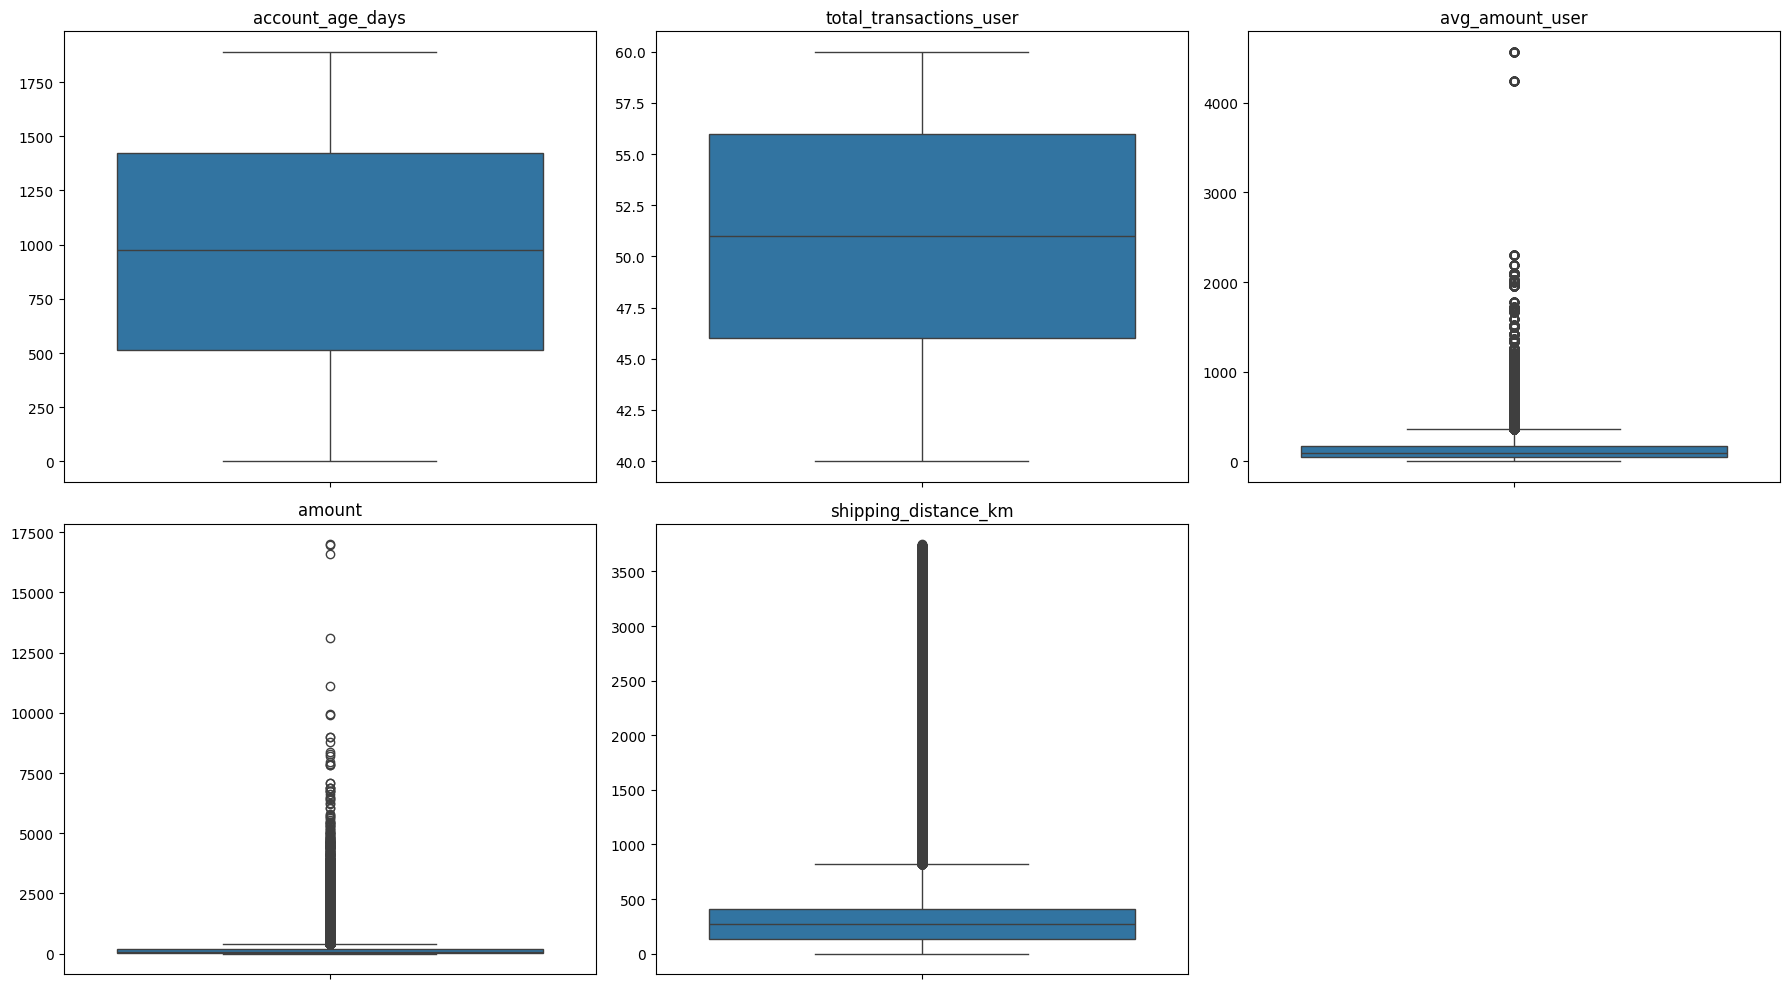

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = continuous_features

rows = 2
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 10))

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    if i < len(axes):
        sns.boxplot(y=df[feature], ax=axes[i])
        axes[i].set_title(feature)
        axes[i].set_ylabel('')

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [16]:
for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[feature] = df[feature].clip(lower, upper)

In [17]:
capped_summary = []

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    capped_summary.append([feature, Q1, Q3, lower, upper, 0])

capped_df = pd.DataFrame(capped_summary, columns=['feature','Q1','Q3','lower_bound','upper_bound','outlier_count'])

capped_df

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,account_age_days,516.00,1425.00,-847.500,2788.500,0
1,total_transactions_user,46.00,56.00,31.000,71.000,0
2,avg_amount_user,46.19,173.45,-144.700,364.340,0
3,amount,42.10,191.11,-181.415,414.625,0
4,shipping_distance_km,136.60,409.18,-272.270,818.050,0


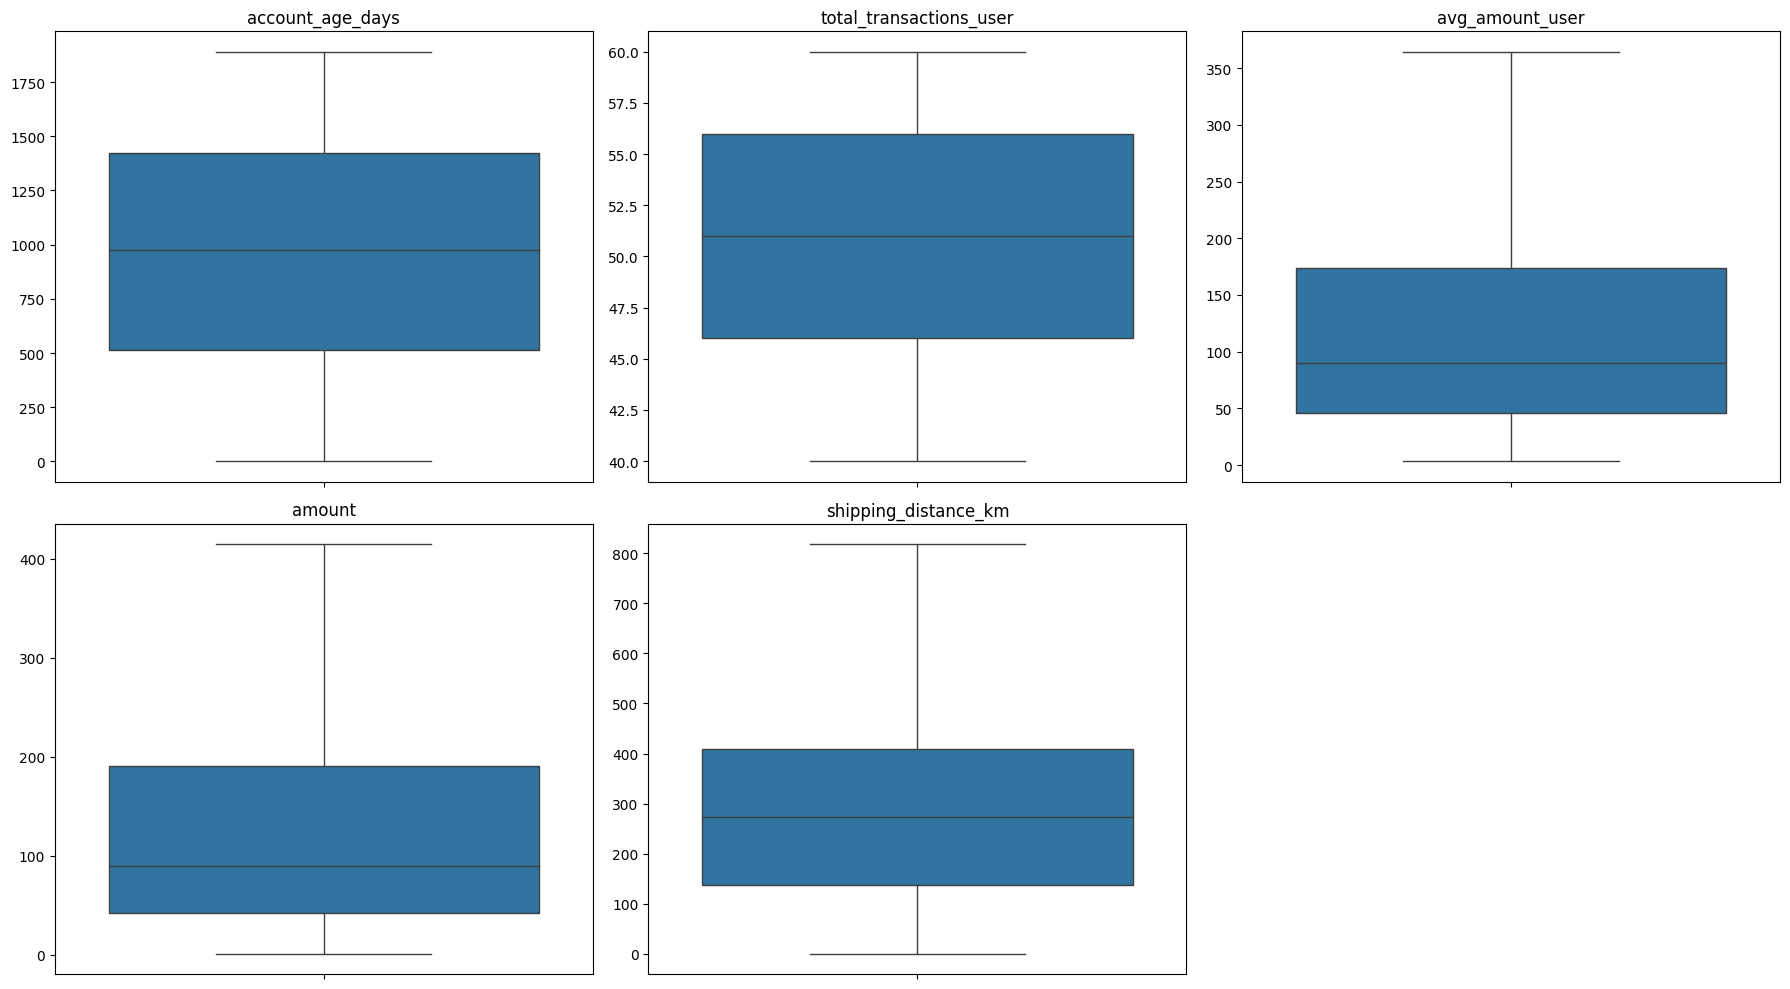

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = continuous_features

rows = 2
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 10))

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    if i < len(axes):
        sns.boxplot(y=df[feature], ax=axes[i])
        axes[i].set_title(feature)
        axes[i].set_ylabel('')

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Data Aggregation

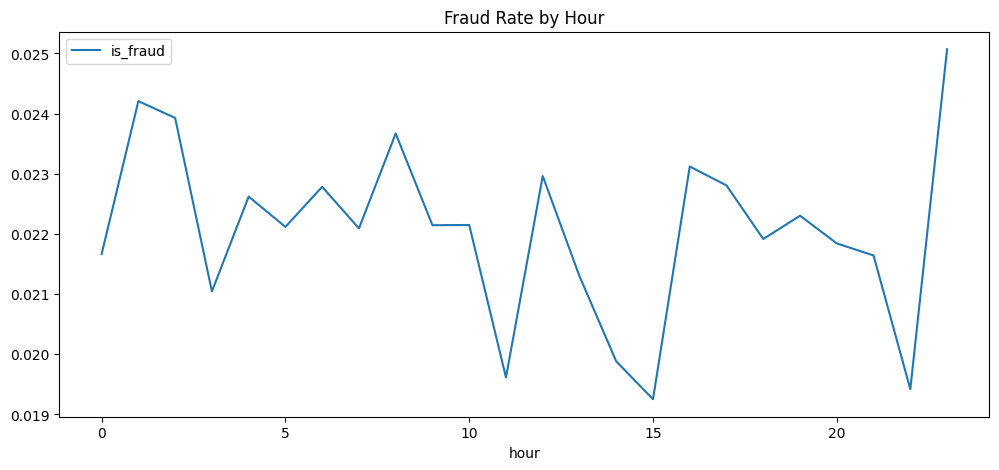

In [19]:
agg_hour = pd.pivot_table(
    data=df,
    index='hour',
    values='is_fraud',
    aggfunc='mean'
)

plt.figure(figsize=(12,5))
sns.lineplot(data=agg_hour)
plt.title('Fraud Rate by Hour')
plt.show()

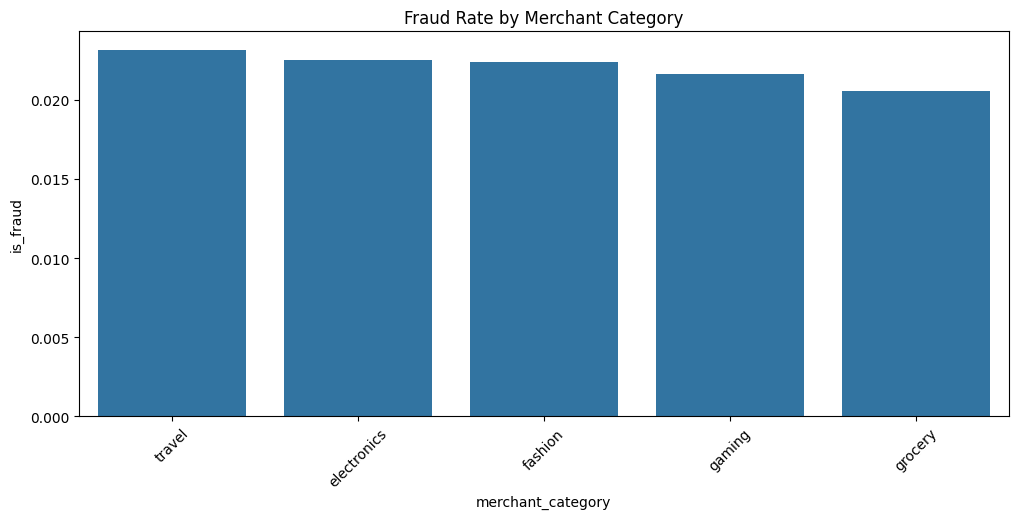

In [20]:
agg_merchant = pd.pivot_table(
    data=df,
    index='merchant_category',
    values='is_fraud',
    aggfunc='mean'
).sort_values(by='is_fraud', ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(x=agg_merchant.index, y=agg_merchant['is_fraud'])
plt.xticks(rotation=45)
plt.title('Fraud Rate by Merchant Category')
plt.show()

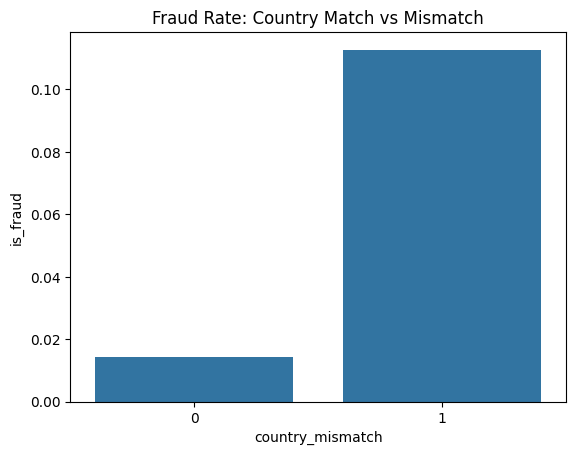

In [21]:
df['country_mismatch'] = (df['country'] != df['bin_country']).astype(int)

agg_mismatch = pd.pivot_table(
    data=df,
    index='country_mismatch',
    values='is_fraud',
    aggfunc='mean'
)

sns.barplot(x=agg_mismatch.index, y=agg_mismatch['is_fraud'])
plt.title('Fraud Rate: Country Match vs Mismatch')
plt.show()

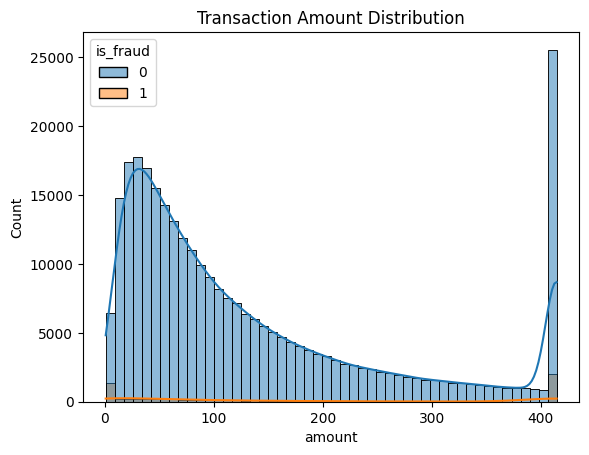

In [22]:
sns.histplot(data=df, x='amount', hue='is_fraud', bins=50, kde=True)
plt.title('Transaction Amount Distribution')
plt.show()

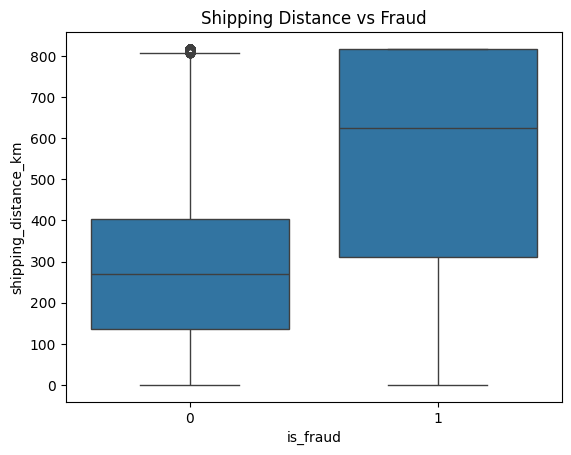

In [23]:
sns.boxplot(x='is_fraud', y='shipping_distance_km', data=df)
plt.title('Shipping Distance vs Fraud')
plt.show()

# Feature Scaling

In [24]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
import sklearn.neighbors
import pandas as pd
from sklearn.utils import shuffle

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

X_processed = X[numerical_cols]

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

In [25]:
import numpy as np
import sklearn.neighbors
import pandas as pd

def get_knn(df, n, k, metric):

    """
    Display k nearest neighbors:
    param df: Pandas DataFrame used to find similar objects within it
    param n: number of the object for which k nearest neighbors are sought
    param k: number of k nearest neighbors to be displayed
    param metric: name of the distance metric
    """

    nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors = k, metric = metric, algorithm = 'brute')
    nbrs.fit(df[continuous_features])
    query_point = df[continuous_features].iloc[[n]]
    nbrs_distances, nbrs_indices = nbrs.kneighbors(query_point, k, return_distance=True)

    df_res = pd.concat([
        df.iloc[nbrs_indices[0]],
        pd.DataFrame(nbrs_distances.T, index=nbrs_indices[0], columns=['distance'])
        ], axis=1)

    return df_res

In [26]:
get_knn(df, 1, 50, 'euclidean')

,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,hour,day,month,weekday,country_mismatch,distance
1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,149.62,0,20,9,1,1,0,0.000000
184981,137,43,137.56,105.77,GB,GB,app,travel,0,1,1,1,147.47,0,8,24,1,2,0,12.194109
254717,150,43,148.66,104.76,DE,DE,app,electronics,0,1,1,1,142.23,0,1,13,4,5,0,12.728103
31,141,47,147.93,119.62,FR,FR,web,gaming,0,1,1,1,141.98,0,14,6,7,5,0,13.990282
43,141,47,147.93,123.80,FR,FR,app,electronics,0,1,1,1,156.49,0,19,4,10,4,0,17.320707
254731,150,43,148.66,119.08,DE,DE,app,grocery,0,1,1,1,136.36,0,19,26,6,2,0,19.958780
2,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,164.08,0,6,12,1,4,0,21.226945
296488,125,52,140.01,100.30,IT,IT,web,gaming,0,1,0,0,161.30,0,16,1,7,0,0,23.192861
223886,126,58,137.10,99.81,ES,ES,app,grocery,0,1,1,1,144.60,0,8,24,3,6,0,23.535875
87260,159,59,148.58,116.89,TR,TR,app,fashion,0,0,0,1,143.18,0,16,22,7,0,0,24.304654


In [27]:
get_knn(df, 1, 50, 'manhattan')

,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,hour,day,month,weekday,country_mismatch,distance
1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,149.62,0,20,9,1,1,0,0.00
31,141,47,147.93,119.62,FR,FR,web,gaming,0,1,1,1,141.98,0,14,6,7,5,0,19.36
184981,137,43,137.56,105.77,GB,GB,app,travel,0,1,1,1,147.47,0,8,24,1,2,0,22.65
43,141,47,147.93,123.80,FR,FR,app,electronics,0,1,1,1,156.49,0,19,4,10,4,0,22.77
254717,150,43,148.66,104.76,DE,DE,app,electronics,0,1,1,1,142.23,0,1,13,4,5,0,24.26
2,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,164.08,0,6,12,1,4,0,30.00
33,141,47,147.93,94.76,FR,FR,web,fashion,0,1,1,1,174.34,0,10,17,7,2,0,37.86
254731,150,43,148.66,119.08,DE,DE,app,grocery,0,1,1,1,136.36,0,19,26,6,2,0,38.17
87260,159,59,148.58,116.89,TR,TR,app,fashion,0,0,0,1,143.18,0,16,22,7,0,0,46.08
279953,161,43,136.83,100.63,DE,DE,app,travel,1,0,0,0,155.21,0,4,21,9,5,0,47.96


In [28]:
feature_names = continuous_features

In [29]:
transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names])
df_scaled = df.copy()
df_scaled[feature_names] = df_scaled[feature_names].astype(float)
df_scaled.loc[:, feature_names] = transformer_mas.transform(df_scaled[feature_names])

In [30]:
get_knn(df_scaled, 1, 10, 'manhattan')

,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,hour,day,month,weekday,country_mismatch,distance
1,0.074603,0.783333,0.406022,0.260235,FR,FR,web,travel,0,0,0,0,0.182898,0,20,9,1,1,0,0.000000
31,0.074603,0.783333,0.406022,0.288502,FR,FR,web,gaming,0,1,1,1,0.173559,0,14,6,7,5,0,0.037606
43,0.074603,0.783333,0.406022,0.298583,FR,FR,app,electronics,0,1,1,1,0.191296,0,19,4,10,4,0,0.046746
2,0.074603,0.783333,0.406022,0.222756,FR,FR,app,travel,1,1,1,1,0.200575,0,6,12,1,4,0,0.055156
33,0.074603,0.783333,0.406022,0.228544,FR,FR,web,fashion,0,1,1,1,0.213117,0,10,17,7,2,0,0.061909
254717,0.079365,0.716667,0.408025,0.252662,DE,DE,app,electronics,0,1,1,1,0.173865,0,1,13,4,5,0,0.090039
22570,0.034921,0.783333,0.408986,0.252035,RO,RO,web,gaming,1,0,0,0,0.226099,1,6,12,8,0,0,0.094047
184981,0.072487,0.716667,0.377559,0.255098,GB,GB,app,travel,0,1,1,1,0.180270,0,8,24,1,2,0,0.105011
44462,0.044974,0.816667,0.410331,0.249647,ES,ES,app,gaming,0,1,1,1,0.213813,0,19,20,7,5,0,0.108775
279693,0.118519,0.750000,0.390981,0.262623,FR,FR,web,electronics,1,0,1,1,0.165931,0,23,19,5,6,0,0.111644


## Normalization

In [31]:
from sklearn.preprocessing import MinMaxScaler

std = MinMaxScaler().fit(X_train)

X_train_std = std.transform(X_train)

X_test_std = std.transform(X_test)

## Standardization

In [32]:
beforeScaling_lr = LogisticRegression(random_state = 42)

In [33]:
beforeScaling_lr = LogisticRegression(random_state = 42)
beforeScaling_lr.fit(X_train, y_train)
y_predict_valid_lr = beforeScaling_lr.predict(X_test)
y_probability_valid_lr = beforeScaling_lr.predict_proba(X_test)[:, 1]
print('F1 score =', f1_score(y_test, y_predict_valid_lr))
print('AUC-ROC score =', roc_auc_score(y_test, y_probability_valid_lr))

F1 score = 0.39329608938547483
AUC-ROC score = 0.9176271763079993


In [34]:
scaler = StandardScaler()

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [36]:
afterScaling_lr = LogisticRegression(random_state = 42)

In [37]:
afterScaling_lr = LogisticRegression(random_state = 42)
afterScaling_lr.fit(X_train_scaled, y_train)
y_predict_valid_lr = afterScaling_lr.predict(X_test_scaled)
y_probability_valid_lr = afterScaling_lr.predict_proba(X_test_scaled)[:, 1]
print('F1 score =', f1_score(y_test, y_predict_valid_lr))
print('AUC-ROC score =', roc_auc_score(y_test, y_probability_valid_lr))

F1 score = 0.40982691233947516
AUC-ROC score = 0.9212002311370897


# Feature Selection

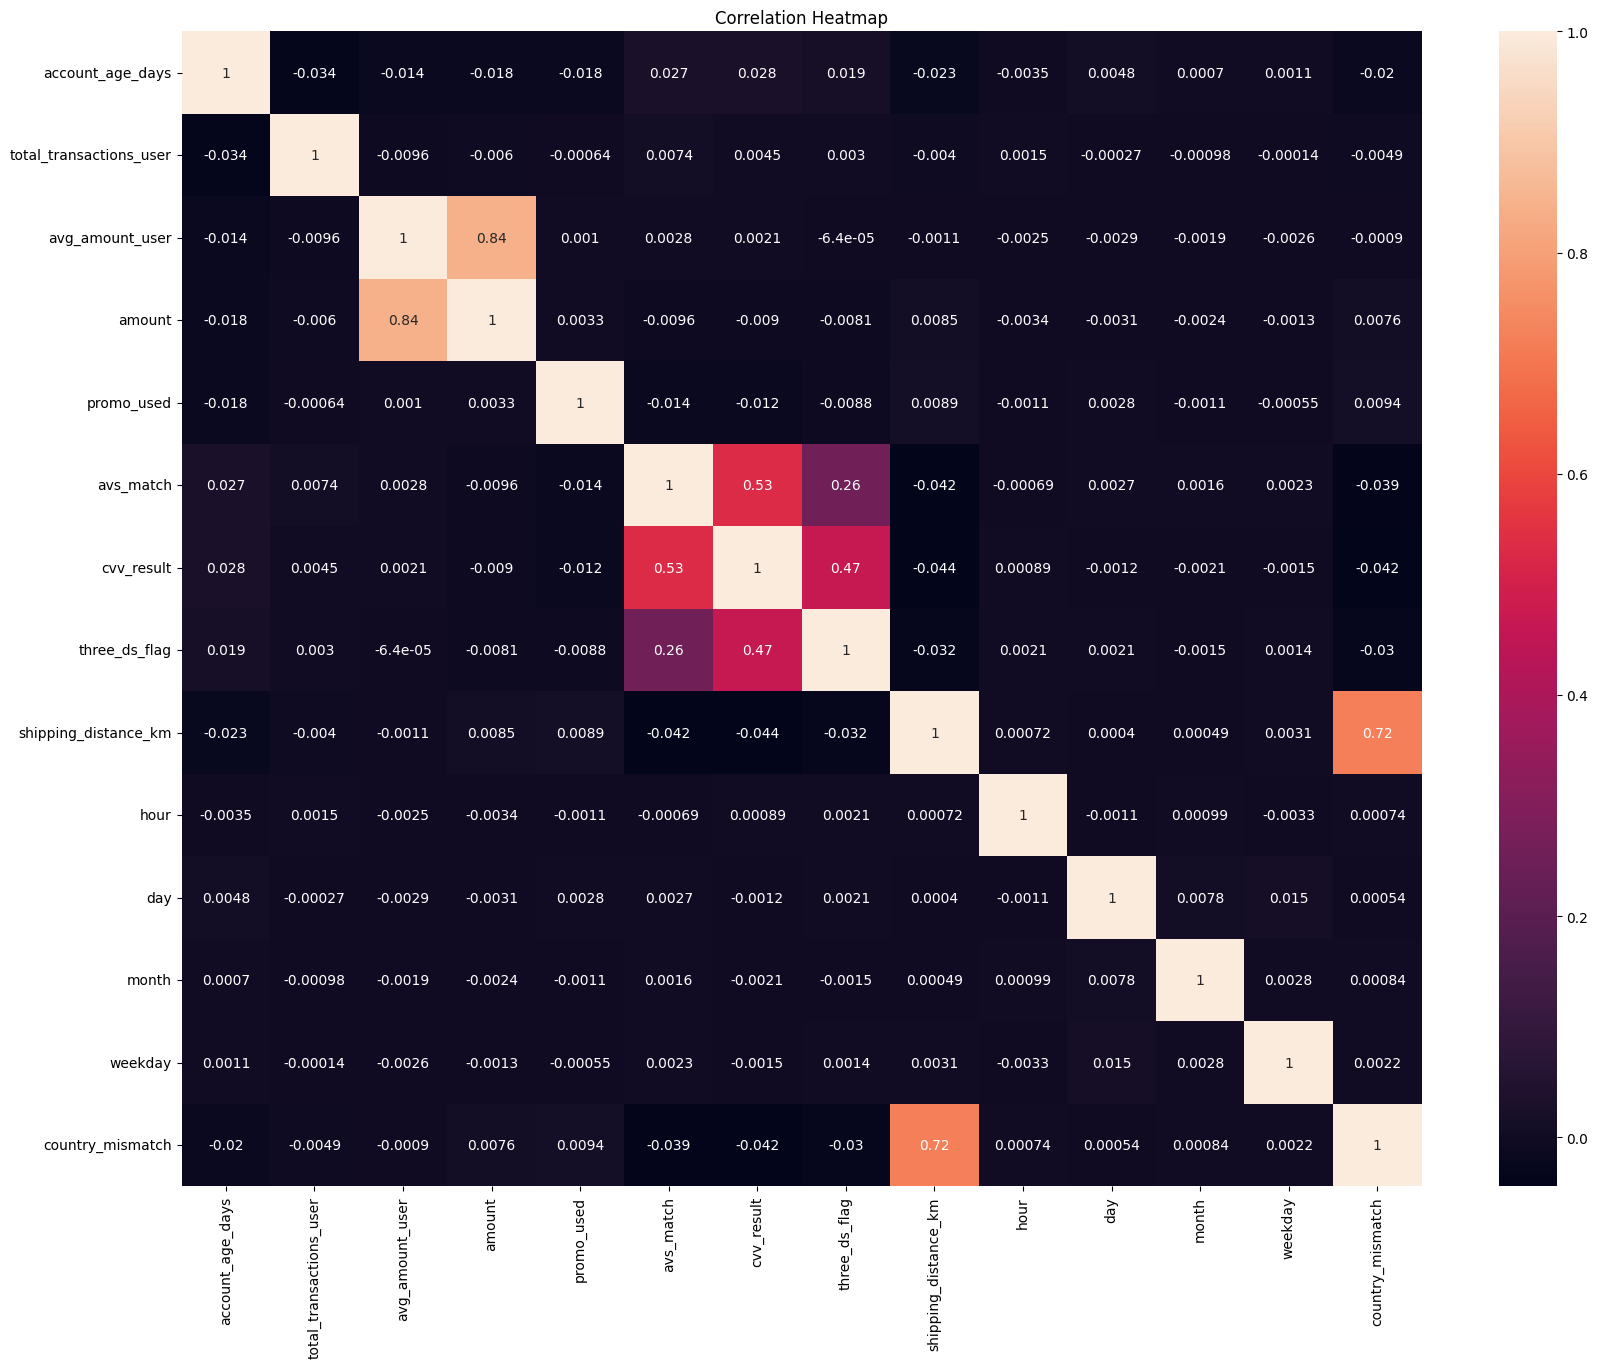

In [38]:
plt.figure(figsize=(20,15))
heatmap = sns.heatmap(X_processed.corr(), annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12});

In [39]:
correlation_matrix = X_processed.corr()
display(correlation_matrix)

,account_age_days,total_transactions_user,avg_amount_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,hour,day,month,weekday,country_mismatch
account_age_days,1.000000,-0.034347,-0.014343,-0.018120,-0.018416,0.026525,0.027605,0.018643,-0.022637,-0.003458,0.004761,0.000696,0.001147,-0.019776
total_transactions_user,-0.034347,1.000000,-0.009590,-0.005989,-0.000636,0.007444,0.004464,0.002968,-0.004027,0.001508,-0.000266,-0.000976,-0.000144,-0.004857
avg_amount_user,-0.014343,-0.009590,1.000000,0.843178,0.001022,0.002845,0.002083,-0.000064,-0.001088,-0.002537,-0.002895,-0.001920,-0.002574,-0.000904
amount,-0.018120,-0.005989,0.843178,1.000000,0.003274,-0.009608,-0.008964,-0.008075,0.008460,-0.003373,-0.003079,-0.002441,-0.001270,0.007616
promo_used,-0.018416,-0.000636,0.001022,0.003274,1.000000,-0.013678,-0.012061,-0.008786,0.008868,-0.001148,0.002796,-0.001096,-0.000554,0.009394
avs_match,0.026525,0.007444,0.002845,-0.009608,-0.013678,1.000000,0.531155,0.255365,-0.041605,-0.000691,0.002694,0.001610,0.002324,-0.038995
cvv_result,0.027605,0.004464,0.002083,-0.008964,-0.012061,0.531155,1.000000,0.469381,-0.044270,0.000893,-0.001181,-0.002056,-0.001479,-0.042188
three_ds_flag,0.018643,0.002968,-0.000064,-0.008075,-0.008786,0.255365,0.469381,1.000000,-0.031643,0.002144,0.002123,-0.001536,0.001361,-0.029676
shipping_distance_km,-0.022637,-0.004027,-0.001088,0.008460,0.008868,-0.041605,-0.044270,-0.031643,1.000000,0.000723,0.000405,0.000486,0.003078,0.719583
hour,-0.003458,0.001508,-0.002537,-0.003373,-0.001148,-0.000691,0.000893,0.002144,0.000723,1.000000,-0.001110,0.000994,-0.003276,0.000742


In [40]:
df.drop('avg_amount_user', axis=1, inplace=True)

In [41]:
df_numeric_for_corr = pd.concat([X_processed, y], axis=1)
df_numeric_for_corr.corr()['is_fraud'].sort_values()

,is_fraud
avs_match,-0.223299
cvv_result,-0.218982
three_ds_flag,-0.162160
account_age_days,-0.120340
total_transactions_user,-0.017093
hour,-0.001911
month,-0.001106
avg_amount_user,-0.000848
weekday,0.000042
day,0.001353


In [42]:
df_numeric_for_corr.corr()['is_fraud'][df_numeric_for_corr.corr()['is_fraud']>0.1]

,is_fraud
shipping_distance_km,0.189741
country_mismatch,0.181083
is_fraud,1.000000


In [43]:
df_numeric_for_corr.corr()['is_fraud'][df_numeric_for_corr.corr()['is_fraud']<-0.1]

,is_fraud
account_age_days,-0.120340
avs_match,-0.223299
cvv_result,-0.218982
three_ds_flag,-0.162160


In [44]:
outliers = df[[
                     'shipping_distance_km',
                     'country_mismatch',
                     'account_age_days',
                     'avs_match',
                     'cvv_result',
                     'three_ds_flag']].copy()

In [45]:
from sklearn.neighbors import LocalOutlierFactor

model = LocalOutlierFactor(n_neighbors=20, contamination=df['is_fraud'].mean(), novelty=True)

model.fit(outliers)

outliers.loc[:, 'is_outlier'] = (model.predict(outliers) == -1)
outliers_knn = outliers['is_outlier'].sum()

print("Number of Anomalies: ", outliers_knn)

Number of Anomalies:  5877


In [46]:
outlier_keys = list(outliers[outliers['is_outlier'] == True].index)
good_keys = list(set(outliers.index) - set(outlier_keys))

In [47]:
df = df.drop(outlier_keys)
df.shape

(293818, 18)

# Handling Imbalanced Data

In [48]:
df['is_fraud'].value_counts()/df.shape[0] * 100

,count
is_fraud,
0,98.152598
1,1.847402


## Upsampling

In [49]:
def upsample (features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle (features_upsampled, target_upsampled, random_state = 42)

    return features_upsampled, target_upsampled

In [50]:
y_train.value_counts()

,count
is_fraud,
0,234466
1,5290


In [51]:
features_upsampled, target_upsampled = upsample(X_train, y_train, 4)

In [52]:
target_upsampled.value_counts()

,count
is_fraud,
0,234466
1,21160


## Downsampling

In [53]:
def downsample (features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_downsampled = pd.concat([features_zeros.sample(frac=fraction, random_state = 42)] + [features_ones])
    target_downsampled = pd.concat([target_zeros.sample(frac=fraction, random_state = 42)] + [target_ones])

    features_downsampled, target_downsampled = shuffle (features_downsampled, target_downsampled, random_state = 42)

    return features_downsampled, target_downsampled

In [54]:
y_train.value_counts()

,count
is_fraud,
0,234466
1,5290


In [55]:
features_downsampled, target_downsampled = downsample(X_train, y_train, 0.3)

In [56]:
target_downsampled.value_counts()

,count
is_fraud,
0,70340
1,5290


## SMOTE

In [57]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: is_fraud
0    234466
1      5290
Name: count, dtype: int64
After SMOTE: is_fraud
0    234466
1    234466
Name: count, dtype: int64


# Encoding Categorical Features

In [58]:
df_categorical = ['country', 'bin_country', 'channel', 'merchant_category']

In [59]:
df = pd.get_dummies(df, drop_first=True, columns = df_categorical)

In [60]:
df.head()

,account_age_days,total_transactions_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,hour,...,bin_country_NL,bin_country_PL,bin_country_RO,bin_country_TR,bin_country_US,channel_web,merchant_category_fashion,merchant_category_gaming,merchant_category_grocery,merchant_category_travel
0,141,47,84.75,0,1,1,1,370.95,0,4,...,False,False,False,False,False,True,False,False,False,True
1,141,47,107.90,0,0,0,0,149.62,0,20,...,False,False,False,False,False,True,False,False,False,True
2,141,47,92.36,1,1,1,1,164.08,0,6,...,False,False,False,False,False,False,False,False,False,True
3,141,47,112.47,0,1,1,1,397.40,0,17,...,False,False,False,False,False,True,True,False,False,False
4,141,47,132.91,0,1,1,1,818.05,0,1,...,False,False,False,False,True,True,False,False,False,False


In [61]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Feature Selection for Regression

## Correlation Analysis

In [62]:
import pandas as pd
correlation_matrix = df.corr()
print(correlation_matrix["is_fraud"].sort_values(ascending=False))

is_fraud                     1.000000
shipping_distance_km         0.151575
country_mismatch             0.130593
channel_web                  0.086294
promo_used                   0.070674
amount                       0.047640
country_TR                   0.013117
bin_country_TR               0.009842
country_RO                   0.005149
bin_country_RO               0.004505
merchant_category_travel     0.003233
country_PL                   0.003149
country_ES                   0.002783
country_US                   0.002221
bin_country_PL               0.001607
bin_country_ES               0.001414
merchant_category_fashion    0.001207
weekday                      0.000362
bin_country_US              -0.000027
bin_country_GB              -0.000249
bin_country_IT              -0.000437
bin_country_FR              -0.000565
merchant_category_gaming    -0.000604
day                         -0.000672
country_GB                  -0.000752
month                       -0.000766
country_FR  

## Univariate Selection

In [63]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
print(feature_scores.sort_values(by='Score', ascending=False))

                      Feature         Score
4                   avs_match  12177.060378
5                  cvv_result  11270.633471
7        shipping_distance_km   6909.193998
6               three_ds_flag   6019.791692
12           country_mismatch   5097.837033
0            account_age_days   4752.376421
31                channel_web   2204.345047
3                  promo_used   1474.927195
2                      amount    668.349626
1     total_transactions_user     53.964580
20                 country_TR     50.564608
17                 country_NL     34.299232
29             bin_country_TR     28.465250
34  merchant_category_grocery      9.099195
26             bin_country_NL      9.088144
19                 country_RO      7.791420
28             bin_country_RO      5.962046
35   merchant_category_travel      3.070413
18                 country_PL      2.913521
13                 country_ES      2.276185
21                 country_US      1.449367
8                        hour   

## Recursive Feature Elimination

In [64]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Initialize the model (LinearRegression here, but you can use others)
model = LinearRegression()

# Applying RFE
rfe = RFE(estimator=model, n_features_to_select=5)  # Change n_features_to_select as needed
rfe.fit(X, y)

# Displaying ranking of features
feature_ranking = pd.DataFrame({'Feature': X.columns, 'Ranking': rfe.ranking_})
print(feature_ranking.sort_values(by='Ranking'))

                      Feature  Ranking
3                  promo_used        1
6               three_ds_flag        1
5                  cvv_result        1
4                   avs_match        1
12           country_mismatch        1
31                channel_web        2
17                 country_NL        3
26             bin_country_NL        4
20                 country_TR        5
13                 country_ES        6
22             bin_country_ES        7
18                 country_PL        8
27             bin_country_PL        9
21                 country_US       10
30             bin_country_US       11
29             bin_country_TR       12
19                 country_RO       13
15                 country_GB       14
14                 country_FR       15
16                 country_IT       16
28             bin_country_RO       17
34  merchant_category_grocery       18
33   merchant_category_gaming       19
23             bin_country_FR       20
24             bin_countr

## Lasso Regression

In [65]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

# Applying Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X, y)

lasso_selector = SelectFromModel(lasso, prefit=True)

selected_features = pd.DataFrame({'Feature': X.columns, 'Selected': lasso_selector.get_support()})
print(selected_features[selected_features['Selected'] == True])

                   Feature  Selected
0         account_age_days      True
1  total_transactions_user      True
2                   amount      True
7     shipping_distance_km      True


## Feature Importance from Tree-based Models

In [66]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
print(feature_importance.sort_values(by='Importance', ascending=False))

                      Feature  Importance
0            account_age_days    0.298744
2                      amount    0.163771
7        shipping_distance_km    0.100870
4                   avs_match    0.097293
12           country_mismatch    0.092433
9                         day    0.031197
8                        hour    0.030151
1     total_transactions_user    0.028587
10                      month    0.021692
11                    weekday    0.018754
6               three_ds_flag    0.015060
31                channel_web    0.014938
3                  promo_used    0.013345
33   merchant_category_gaming    0.005283
32  merchant_category_fashion    0.004981
5                  cvv_result    0.004808
35   merchant_category_travel    0.004649
34  merchant_category_grocery    0.004636
20                 country_TR    0.003150
29             bin_country_TR    0.003041
30             bin_country_US    0.003019
21                 country_US    0.002857
18                 country_PL    0

## Dimensionality Reduction Techniques (PCA)

In [67]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
principal_components = pca.fit_transform(X)

explained_variance = pd.DataFrame({'Component': range(1, pca.n_components_ + 1), 'Explained Variance': pca.explained_variance_ratio_})
print(explained_variance)

   Component  Explained Variance
0          1            0.837415
1          2            0.115477
2          3            0.046572
3          4            0.000235
4          5            0.000146


## Comaprison

In [68]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

In [69]:
X_train_small = X_train.sample(80000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

X_test_small = X_test

In [70]:
X_train_rfe = rfe.transform(X_train_small)
X_test_rfe = rfe.transform(X_test_small)

model.fit(X_train_rfe, y_train_small)
y_pred = model.predict(X_test_rfe)

from sklearn.metrics import mean_squared_error
print("RFE MSE:", mean_squared_error(y_test, y_pred))

RFE MSE: 0.01524184037608874


In [71]:
corr_features = [
    'avs_match',
    'cvv_result',
    'three_ds_flag',
    'account_age_days',
    'shipping_distance_km',
    'country_mismatch',
    'amount'
]

X_train_corr = X_train_small[corr_features]
X_test_corr = X_test_small[corr_features]

model.fit(X_train_corr, y_train_small)
y_pred = model.predict(X_test_corr)

print("Correlation MSE:", mean_squared_error(y_test, y_pred))

Correlation MSE: 0.00700157548592516


In [72]:
uni_features = feature_scores.sort_values(by='Score', ascending=False).head(7)['Feature'].values

X_train_uni = X_train_small[uni_features]
X_test_uni = X_test_small[uni_features]

model.fit(X_train_uni, y_train_small)
y_pred = model.predict(X_test_uni)

print("Univariate MSE:", mean_squared_error(y_test, y_pred))

Univariate MSE: 0.008583949333962173


In [73]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
import pandas as pd
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor

# Re-initialize the RandomForestRegressor model locally to ensure correct type
model = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

# Initialize Lasso for feature selection
lasso = Lasso(alpha=0.01)
lasso.fit(X, y)

# Create a SelectFromModel object for Lasso feature selection
# Assign it to a new variable name, e.g., 'lasso_feature_selector', to avoid overwriting the RandomForestRegressor 'model'
lasso_feature_selector = SelectFromModel(lasso, prefit=True)

# Generate the 'selected_features' DataFrame based on the current Lasso feature selection
selected_features = pd.DataFrame({'Feature': X.columns, 'Selected': lasso_feature_selector.get_support()})

# Extract the names of the selected features
lasso_features = selected_features.loc[selected_features['Selected'] == True, 'Feature'].tolist()

# Transform the data using the selected features
X_train_lasso = X_train_small[lasso_features]
X_test_lasso = X_test_small[lasso_features]

# Use the RandomForestRegressor 'model' (defined in this cell) to fit and predict
model.fit(X_train_lasso, y_train_small)
y_pred = model.predict(X_test_lasso)

print("Lasso MSE:", mean_squared_error(y_test, y_pred))

Lasso MSE: 0.009546496895110083


In [74]:
tree_features = feature_importance.sort_values(by='Importance', ascending=False).head(7)['Feature'].values

X_train_tree = X_train_small[tree_features]
X_test_tree = X_test_small[tree_features]

model.fit(X_train_tree, y_train_small)
y_pred = model.predict(X_test_tree)

print("Tree-Based MSE:", mean_squared_error(y_test, y_pred))

Tree-Based MSE: 0.007250396893381837


In [75]:
model.fit(X_train_small, y_train_small)
y_pred = model.predict(X_test_small)

print("Full Model MSE:", mean_squared_error(y_test, y_pred))

Full Model MSE: 0.006786662629283188


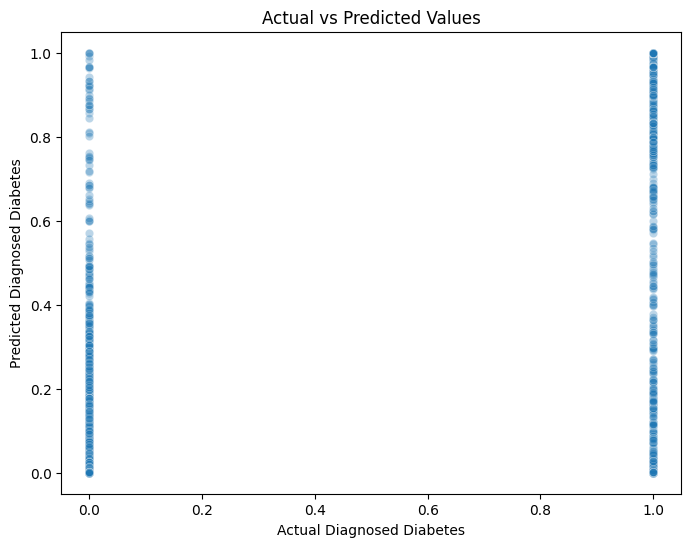

In [76]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.xlabel("Actual Diagnosed Diabetes")
plt.ylabel("Predicted Diagnosed Diabetes")
plt.title("Actual vs Predicted Values")
plt.show()

# Logistic Regression

In [77]:
df['security_score'] = (
    df['avs_match'] +
    df['cvv_result'] +
    df['three_ds_flag']
)

In [78]:
df['geo_risk'] = df['country_mismatch'] * df['shipping_distance_km']

In [79]:
df['user_activity_score'] = df['account_age_days'] * df['total_transactions_user']

In [80]:
df['night_transaction'] = df['hour'].apply(lambda x: 1 if (x < 6 or x > 23) else 0)

In [81]:
df.head()

,account_age_days,total_transactions_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,hour,...,bin_country_US,channel_web,merchant_category_fashion,merchant_category_gaming,merchant_category_grocery,merchant_category_travel,security_score,geo_risk,user_activity_score,night_transaction
0,141,47,84.75,0,1,1,1,370.95,0,4,...,False,True,False,False,False,True,3,0.00,6627,1
1,141,47,107.90,0,0,0,0,149.62,0,20,...,False,True,False,False,False,True,0,0.00,6627,0
2,141,47,92.36,1,1,1,1,164.08,0,6,...,False,False,False,False,False,True,3,0.00,6627,0
3,141,47,112.47,0,1,1,1,397.40,0,17,...,False,True,True,False,False,False,3,0.00,6627,0
4,141,47,132.91,0,1,1,1,818.05,0,1,...,True,True,False,False,False,False,3,818.05,6627,1


In [82]:
df.corr()

,account_age_days,total_transactions_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,hour,...,bin_country_US,channel_web,merchant_category_fashion,merchant_category_gaming,merchant_category_grocery,merchant_category_travel,security_score,geo_risk,user_activity_score,night_transaction
account_age_days,1.000000,-0.034324,-0.017792,-0.018136,0.026628,0.028496,0.018798,-0.022076,-0.126163,-0.003868,...,0.017681,-0.011695,-0.000487,-0.001646,0.000539,0.001758,0.031319,-0.021153,0.970123,0.002540
total_transactions_user,-0.034324,1.000000,-0.005197,-0.000665,0.005739,0.003204,0.002506,-0.002269,-0.013551,0.001511,...,0.007152,-0.001371,-0.000684,-0.001891,0.000722,0.000840,0.004881,-0.002129,0.179688,-0.001430
amount,-0.017792,-0.005197,1.000000,0.003430,-0.007511,-0.007215,-0.006445,0.006301,0.047640,-0.003092,...,0.011230,0.001351,0.000040,0.000277,-0.003770,0.002801,-0.009066,0.004898,-0.019446,0.001772
promo_used,-0.018136,-0.000665,0.003430,1.000000,-0.013674,-0.011815,-0.008500,0.008803,0.070674,-0.001285,...,0.002227,0.007568,-0.003833,0.003335,-0.001578,0.002054,-0.014448,0.010098,-0.017522,0.001725
avs_match,0.026628,0.005739,-0.007511,-0.013674,1.000000,0.521332,0.244813,0.000718,-0.199487,-0.000916,...,0.001443,-0.018637,-0.000537,0.000319,-0.000216,-0.002869,0.744465,0.018411,0.027244,0.000150
cvv_result,0.028496,0.003204,-0.007215,-0.011815,0.521332,1.000000,0.460771,0.006903,-0.192204,0.000444,...,0.000786,-0.018345,-0.000128,-0.002209,0.001033,-0.000760,0.827422,0.027893,0.028341,-0.001956
three_ds_flag,0.018798,0.002506,-0.006445,-0.008500,0.244813,0.460771,1.000000,0.005151,-0.141693,0.001575,...,0.000068,-0.013421,0.003223,-0.002671,0.001674,-0.001243,0.760548,0.020491,0.018736,-0.000462
shipping_distance_km,-0.022076,-0.002269,0.006301,0.008803,0.000718,0.006903,0.005151,1.000000,0.151575,0.001550,...,-0.002313,0.011948,0.000136,-0.001158,-0.003579,0.004317,0.005426,0.688725,-0.021739,-0.003913
is_fraud,-0.126163,-0.013551,0.047640,0.070674,-0.199487,-0.192204,-0.141693,0.151575,1.000000,-0.002144,...,-0.000027,0.086294,0.001207,-0.000604,-0.005565,0.003233,-0.226874,0.134801,-0.124617,0.002709
hour,-0.003868,0.001511,-0.003092,-0.001285,-0.000916,0.000444,0.001575,0.001550,-0.002144,1.000000,...,-0.000694,0.001414,-0.000296,-0.000131,-0.002552,0.000045,0.000534,0.001939,-0.003396,-0.751133


In [83]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [84]:
cat_cols = [
    'country',
    'bin_country',
    'channel',
    'merchant_category'
]

In [85]:
df.head()

,account_age_days,total_transactions_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,hour,...,bin_country_US,channel_web,merchant_category_fashion,merchant_category_gaming,merchant_category_grocery,merchant_category_travel,security_score,geo_risk,user_activity_score,night_transaction
0,141,47,84.75,0,1,1,1,370.95,0,4,...,0,1,0,0,0,1,3,0.00,6627,1
1,141,47,107.90,0,0,0,0,149.62,0,20,...,0,1,0,0,0,1,0,0.00,6627,0
2,141,47,92.36,1,1,1,1,164.08,0,6,...,0,0,0,0,0,1,3,0.00,6627,0
3,141,47,112.47,0,1,1,1,397.40,0,17,...,0,1,1,0,0,0,3,0.00,6627,0
4,141,47,132.91,0,1,1,1,818.05,0,1,...,1,1,0,0,0,0,3,818.05,6627,1


In [86]:
from sklearn.preprocessing import StandardScaler

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [87]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [88]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(class_weight='balanced')
lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [89]:
y_pred = lr_model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [90]:
a = pd.DataFrame({'Actual value': y_test, 'Predicted value':y_pred})
a.head()

,Actual value,Predicted value
203010,0,0
254746,0,0
150978,0,0
288257,0,1
197067,0,0


In [91]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score

y_pred_default = lr_model.predict(X_test)
y_prob_default = lr_model.predict_proba(X_test)[:, 1]

print('Default Threshold (0.5) Evaluation:')
print(f'F1 Score: {f1_score(y_test, y_pred_default):.4f}')
print(f'AUC-ROC Score: {roc_auc_score(y_test, y_prob_default):.4f}')
print(f'Precision Score (Class 1): {precision_score(y_test, y_pred_default):.4f}')

Default Threshold (0.5) Evaluation:
F1 Score: 0.1174
AUC-ROC Score: 0.8327
Precision Score (Class 1): 0.0639


In [92]:
from sklearn.metrics import confusion_matrix

threshold = 0.9
y_pred_adjusted = (lr_model.predict_proba(X_test)[:, 1] >= threshold).astype(int)

print(f'F1 Score: {f1_score(y_test, y_pred_adjusted):.4f}')
print(f'AUC-ROC Score: {roc_auc_score(y_test, y_prob_default):.4f}')
print(f'Precision Score (Class 1): {precision_score(y_test, y_pred_adjusted):.4f}')

matrix_adjusted = confusion_matrix(y_test, y_pred_adjusted)
cm_df_adjusted = pd.DataFrame(matrix_adjusted, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])
display(cm_df_adjusted)

F1 Score: 0.3437
AUC-ROC Score: 0.8327
Precision Score (Class 1): 0.4410


,Predicted 0,Predicted 1
Actual 0,57251,398
Actual 1,801,314


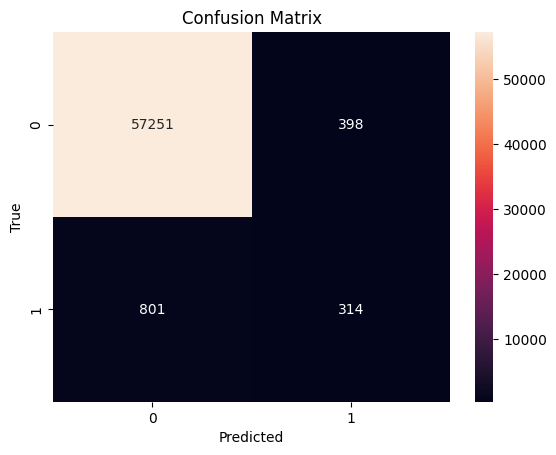

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     57649
           1       0.44      0.28      0.34      1115

    accuracy                           0.98     58764
   macro avg       0.71      0.64      0.67     58764
weighted avg       0.98      0.98      0.98     58764



In [93]:
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
matrix = confusion_matrix(y_test, y_pred_adjusted)
sns.heatmap(matrix, annot=True, fmt="d")
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
print(classification_report(y_test, y_pred_adjusted))

In [94]:
cm_df = pd.DataFrame(matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])
display(cm_df)

,Predicted 0,Predicted 1
Actual 0,57251,398
Actual 1,801,314


# Regularization

In [95]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss

In [96]:
model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

In [97]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [98]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [99]:
y_train_prob = model.predict_proba(X_train)
y_test_prob = model.predict_proba(X_test)

In [100]:
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9864542917432442


In [101]:
print("Train Loss:", log_loss(y_train, y_train_prob))
print("Test Loss:", log_loss(y_test, y_test_prob))

Train Loss: 2.2204460492503136e-16
Test Loss: 0.48823681331660995


In [102]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss

depths = range(1, 21)

train_acc = []
test_acc = []
train_loss = []
test_loss = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)
    y_test_prob = model.predict_proba(X_test)

    # Store metrics
    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

    train_loss.append(log_loss(y_train, y_train_prob))
    test_loss.append(log_loss(y_test, y_test_prob))

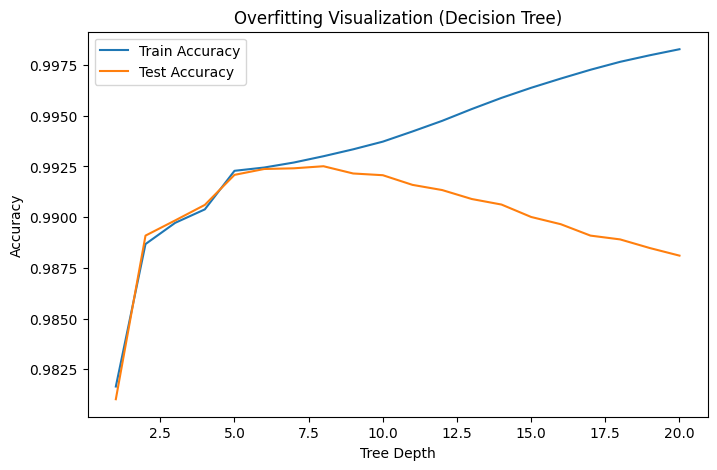

In [103]:
plt.figure(figsize=(8,5))
plt.plot(depths, train_acc, label="Train Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Visualization (Decision Tree)")
plt.legend()
plt.show()

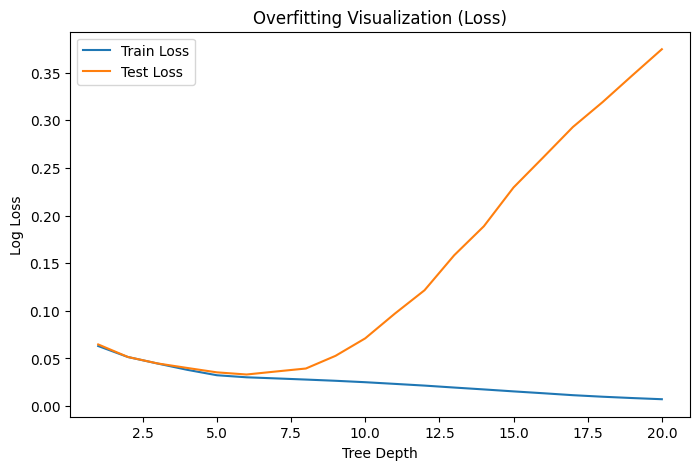

In [104]:
plt.figure(figsize=(8,5))
plt.plot(depths, train_loss, label="Train Loss")
plt.plot(depths, test_loss, label="Test Loss")

plt.xlabel("Tree Depth")
plt.ylabel("Log Loss")
plt.title("Overfitting Visualization (Loss)")
plt.legend()
plt.show()

In [105]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [106]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score

In [107]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_small)
X_test_poly = poly.transform(X_test_small)

# Add scaling for polynomial features
scaler_poly = StandardScaler()
X_train_poly = scaler_poly.fit_transform(X_train_poly)
X_test_poly = scaler_poly.transform(X_test_poly)

## L1

In [108]:
model = SGDClassifier(
    loss='log_loss',
    penalty='l1',         # L1 regularization
    alpha=0.05,         # small regularization strength
    learning_rate='constant',
    eta0=0.001,
    random_state=42
)

In [109]:
epochs = 100
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(epochs):
    model.partial_fit(X_train_poly, y_train_small, classes=np.unique(y_train_small))

    y_train_prob = model.predict_proba(X_train_poly)
    y_val_prob = model.predict_proba(X_test_poly)

    y_train_pred = model.predict(X_train_poly)
    y_val_pred = model.predict(X_test_poly)

    train_losses.append(log_loss(y_train_small, y_train_prob))
    val_losses.append(log_loss(y_test, y_val_prob))
    train_acc.append(accuracy_score(y_train_small, y_train_pred))
    val_acc.append(accuracy_score(y_test, y_val_pred))

In [110]:
def smooth(values, factor=10):
    return [np.mean(values[max(0, i-factor):i+1]) for i in range(len(values))]

train_losses_smooth = smooth(train_losses)
val_losses_smooth = smooth(val_losses)
train_acc_smooth = smooth(train_acc)
val_acc_smooth = smooth(val_acc)

In [111]:
print("Final Epoch Metrics with L1 Regularization:\n")
print(f"Train Loss: {train_losses[-1]:.4f}")
print(f"Validation Loss: {val_losses[-1]:.4f}")
print(f"Train Accuracy: {train_acc[-1]:.4f}")
print(f"Validation Accuracy: {val_acc[-1]:.4f}")

Final Epoch Metrics with L1 Regularization:

Train Loss: 0.0927
Validation Loss: 0.0940
Train Accuracy: 0.9813
Validation Accuracy: 0.9810


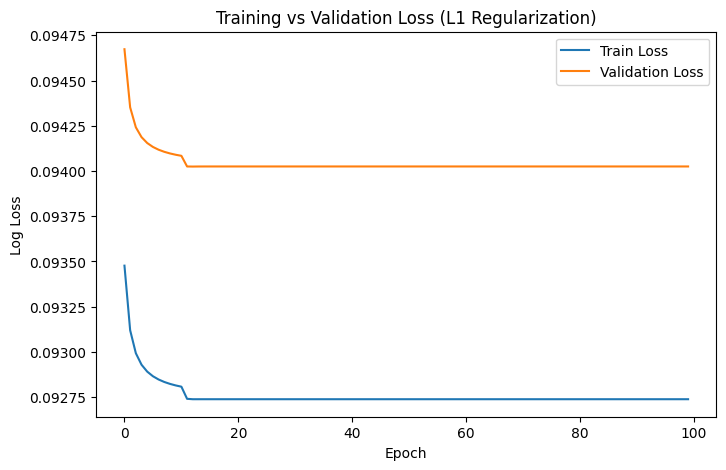

In [112]:
plt.figure(figsize=(8,5))
plt.plot(train_losses_smooth, label='Train Loss')
plt.plot(val_losses_smooth, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Training vs Validation Loss (L1 Regularization)")
plt.legend()
plt.show()

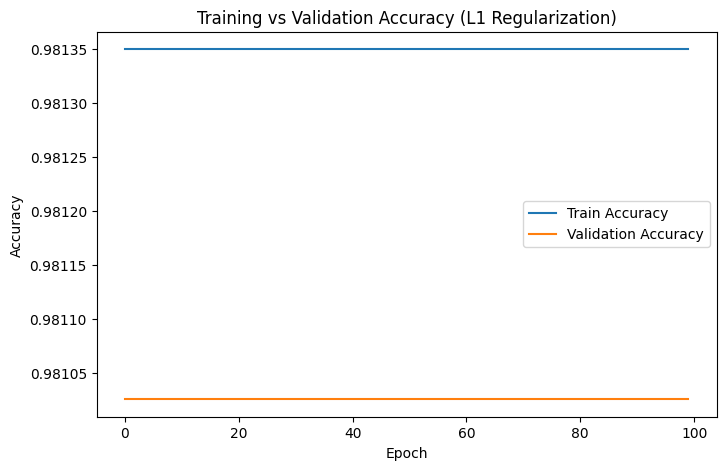

In [113]:
plt.figure(figsize=(8,5))
plt.plot(train_acc_smooth, label='Train Accuracy')
plt.plot(val_acc_smooth, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (L1 Regularization)")
plt.legend()
plt.show()

## L2

In [114]:
model = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.01,
    learning_rate='constant',
    eta0=0.001,
    random_state=42
)

In [115]:
epochs = 100
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(epochs):
    model.partial_fit(X_train_poly, y_train_small, classes=np.unique(y_train_small))

    y_train_prob = model.predict_proba(X_train_poly)
    y_val_prob = model.predict_proba(X_test_poly)

    y_train_pred = model.predict(X_train_poly)
    y_val_pred = model.predict(X_test_poly)

    train_losses.append(log_loss(y_train_small, y_train_prob))
    val_losses.append(log_loss(y_test, y_val_prob))
    train_acc.append(accuracy_score(y_train_small, y_train_pred))
    val_acc.append(accuracy_score(y_test, y_val_pred))

In [116]:
def smooth(values, factor=10):
    return [np.mean(values[max(0, i-factor):i+1]) for i in range(len(values))]

train_losses_smooth = smooth(train_losses)
val_losses_smooth = smooth(val_losses)
train_acc_smooth = smooth(train_acc)
val_acc_smooth = smooth(val_acc)

In [117]:
print("Final Epoch Metrics with L2 Regularization:\n")
print(f"Train Loss: {train_losses[-1]:.4f}")
print(f"Validation Loss: {val_losses[-1]:.4f}")
print(f"Train Accuracy: {train_acc[-1]:.4f}")
print(f"Validation Accuracy: {val_acc[-1]:.4f}")

Final Epoch Metrics with L2 Regularization:

Train Loss: 0.0523
Validation Loss: 0.1336
Train Accuracy: 0.9852
Validation Accuracy: 0.9760


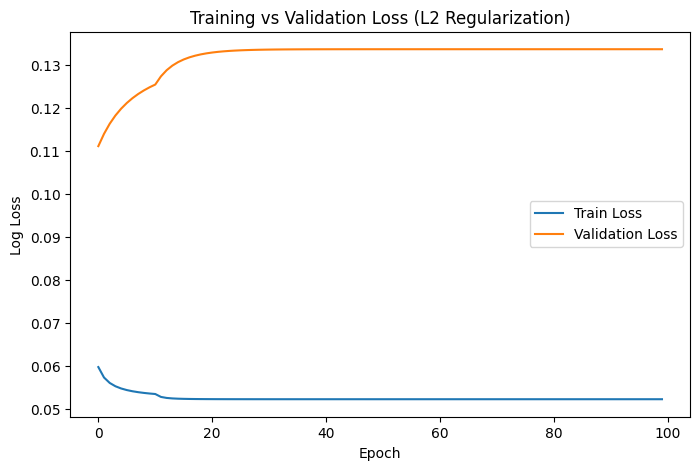

In [118]:
plt.figure(figsize=(8,5))
plt.plot(train_losses_smooth, label='Train Loss')
plt.plot(val_losses_smooth, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Training vs Validation Loss (L2 Regularization)")
plt.legend()
plt.show()

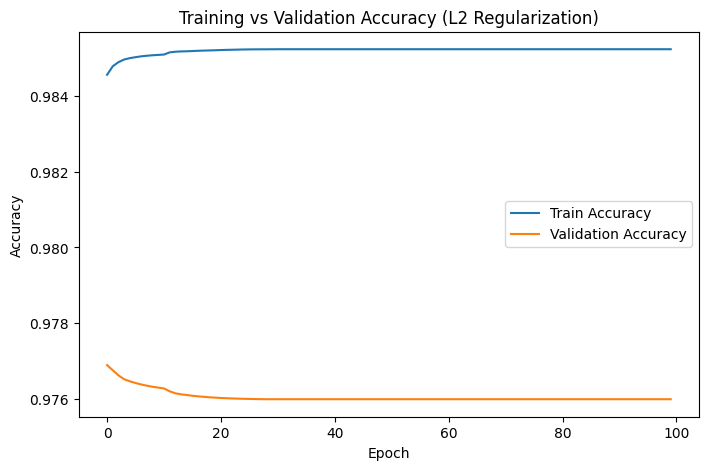

In [119]:
plt.figure(figsize=(8,5))
plt.plot(train_acc_smooth, label='Train Accuracy')
plt.plot(val_acc_smooth, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (L2 Regularization)")
plt.legend()
plt.show()

## Elastic Net

In [120]:
model = SGDClassifier(
    loss='log_loss',
    penalty='elasticnet',
    l1_ratio=0.5,
    alpha=0.01,
    learning_rate='constant',
    eta0=0.001,
    random_state=42
)

In [121]:
epochs = 100
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(epochs):
    model.partial_fit(X_train_poly, y_train_small, classes=np.unique(y_train_small))

    y_train_prob = model.predict_proba(X_train_poly)
    y_val_prob = model.predict_proba(X_test_poly)

    y_train_pred = model.predict(X_train_poly)
    y_val_pred = model.predict(X_test_poly)

    train_losses.append(log_loss(y_train_small, y_train_prob))
    val_losses.append(log_loss(y_test, y_val_prob))
    train_acc.append(accuracy_score(y_train_small, y_train_pred))
    val_acc.append(accuracy_score(y_test, y_val_pred))

In [122]:
def smooth(values, factor=10):
    return [np.mean(values[max(0, i-factor):i+1]) for i in range(len(values))]

In [123]:
train_losses_smooth = smooth(train_losses)
val_losses_smooth = smooth(val_losses)
train_acc_smooth = smooth(train_acc)
val_acc_smooth = smooth(val_acc)

In [124]:
print("Final Epoch Metrics with Elastic Net (L1+L2):\n")
print(f"Train Loss: {train_losses[-1]:.4f}")
print(f"Validation Loss: {val_losses[-1]:.4f}")
print(f"Train Accuracy: {train_acc[-1]:.4f}")
print(f"Validation Accuracy: {val_acc[-1]:.4f}")

Final Epoch Metrics with Elastic Net (L1+L2):

Train Loss: 0.0576
Validation Loss: 0.1118
Train Accuracy: 0.9837
Validation Accuracy: 0.9786


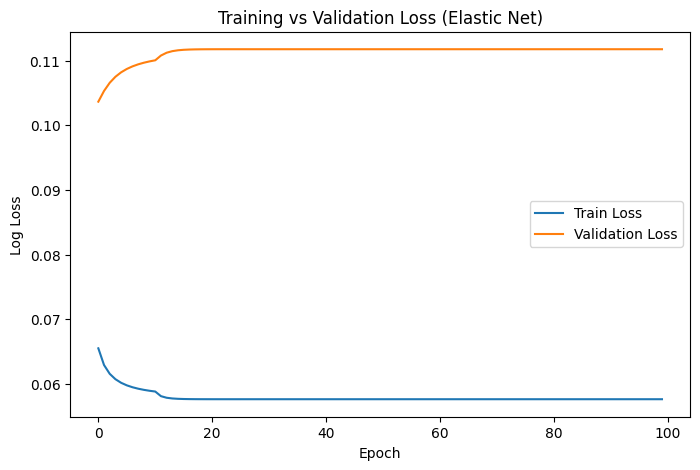

In [125]:
plt.figure(figsize=(8,5))
plt.plot(train_losses_smooth, label='Train Loss')
plt.plot(val_losses_smooth, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Training vs Validation Loss (Elastic Net)")
plt.legend()
plt.show()

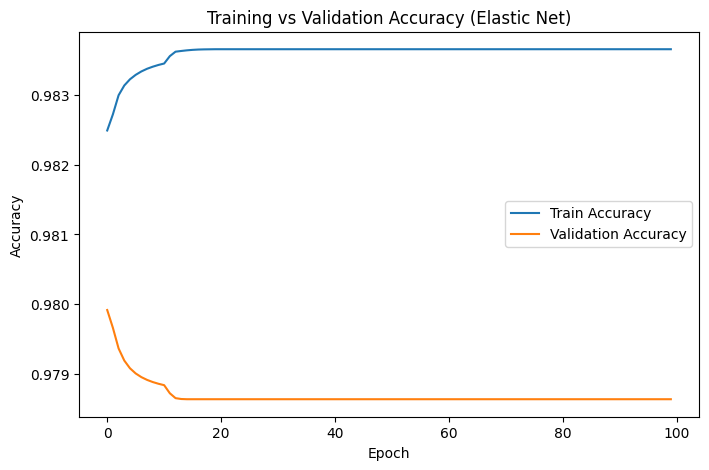

In [126]:
plt.figure(figsize=(8,5))
plt.plot(train_acc_smooth, label='Train Accuracy')
plt.plot(val_acc_smooth, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (Elastic Net)")
plt.legend()
plt.show()

## Early Stopping

In [127]:
# The model initialization has been moved to GkMqhHXZxJKT to ensure it's properly initialized with the correct feature count.

In [128]:
epochs = 500
patience = 20
best_val_loss = np.inf
wait = 0

In [129]:
train_losses, val_losses = [], []
train_acc, val_acc = [], []

In [130]:
model = SGDClassifier(
    loss='log_loss',
    penalty='elasticnet',
    l1_ratio=0.5,
    alpha=0.1,
    learning_rate='constant',
    eta0=0.001,
    random_state=42
)

for epoch in range(epochs):
    model.partial_fit(X_train_poly, y_train_small, classes=np.unique(y_train_small))

    y_train_prob = model.predict_proba(X_train_poly)
    y_val_prob = model.predict_proba(X_test_poly)

    y_train_pred = model.predict(X_train_poly)
    y_val_pred = model.predict(X_test_poly)

    t_loss = log_loss(y_train_small, y_train_prob)
    v_loss = log_loss(y_test, y_val_prob)
    t_acc = accuracy_score(y_train_small, y_train_pred)
    v_acc = accuracy_score(y_test, y_val_pred)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_acc.append(t_acc)
    val_acc.append(v_acc)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        wait = 0
        best_epoch = epoch
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

Early stopping triggered at epoch 23


In [131]:
def smooth(values, factor=10):
    return [np.mean(values[max(0, i-factor):i+1]) for i in range(len(values))]

In [132]:
train_losses_smooth = smooth(train_losses)
val_losses_smooth = smooth(val_losses)
train_acc_smooth = smooth(train_acc)
val_acc_smooth = smooth(val_acc)

In [133]:
print("Final Epoch Metrics with Early Stopping:\n")
print(f"Train Loss: {train_losses[-1]:.4f}")
print(f"Validation Loss: {val_losses[-1]:.4f}")
print(f"Train Accuracy: {train_acc[-1]:.4f}")
print(f"Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Stopped at Epoch: {len(train_losses)} (Best Epoch: {best_epoch+1})")

Final Epoch Metrics with Early Stopping:

Train Loss: 0.0927
Validation Loss: 0.0940
Train Accuracy: 0.9813
Validation Accuracy: 0.9810
Stopped at Epoch: 23 (Best Epoch: 3)


### Training and Validation History Plots

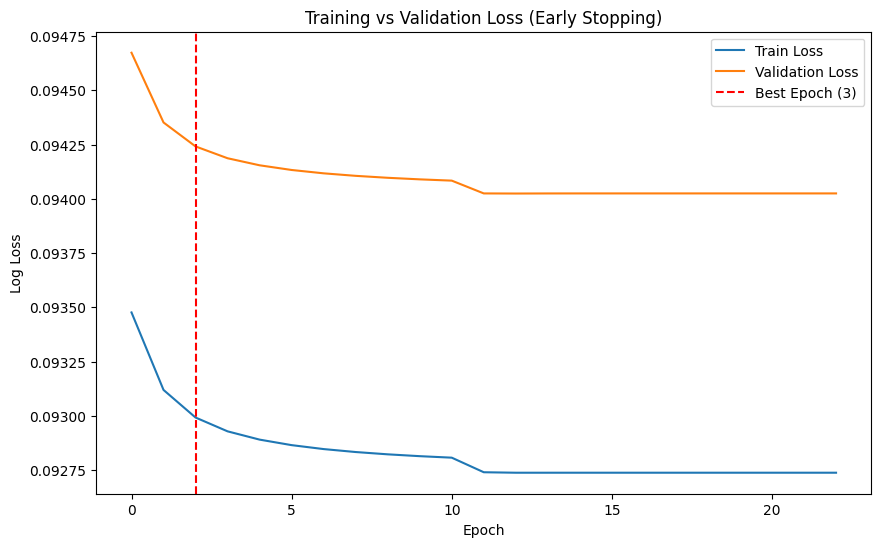

In [134]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses_smooth, label='Train Loss')
plt.plot(val_losses_smooth, label='Validation Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch+1})')
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Training vs Validation Loss (Early Stopping)")
plt.legend()
plt.show()

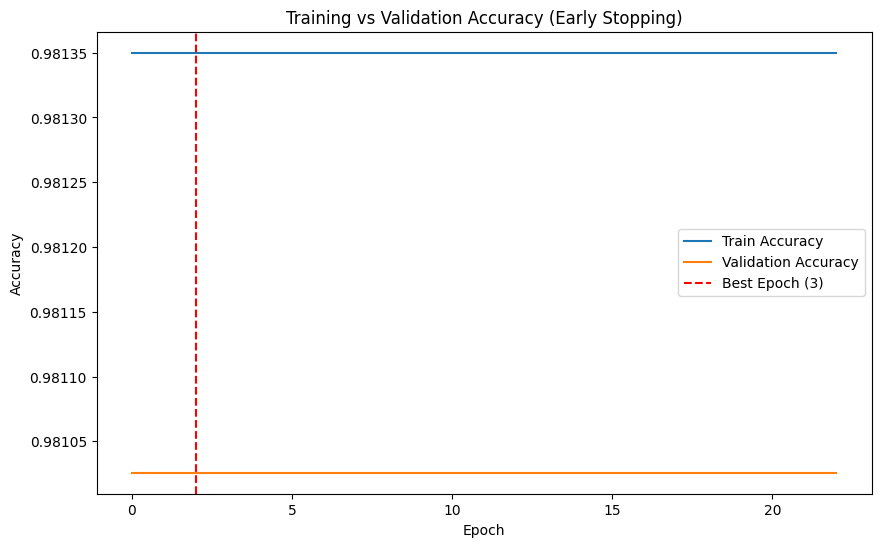

In [135]:
plt.figure(figsize=(10, 6))
plt.plot(train_acc_smooth, label='Train Accuracy')
plt.plot(val_acc_smooth, label='Validation Accuracy')
plt.axvline(best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch+1})')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (Early Stopping)")
plt.legend()
plt.show()

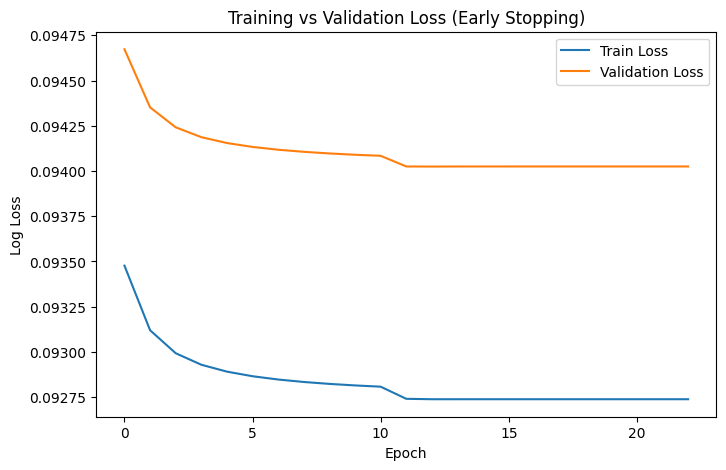

In [136]:
plt.figure(figsize=(8,5))
plt.plot(train_losses_smooth, label='Train Loss')
plt.plot(val_losses_smooth, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Training vs Validation Loss (Early Stopping)")
plt.legend()
plt.show()

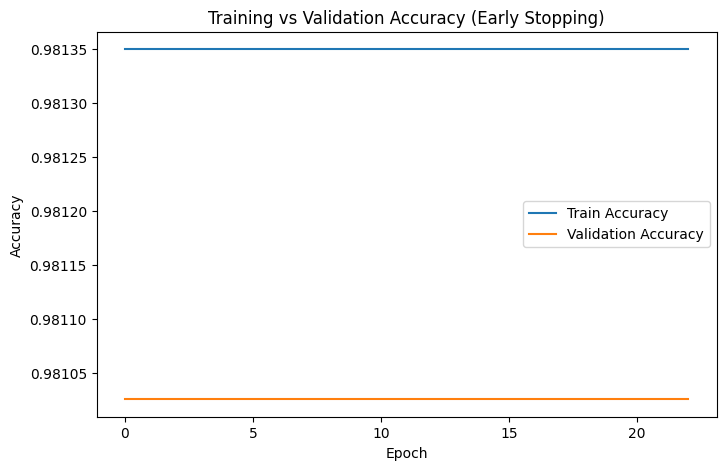

In [137]:
plt.figure(figsize=(8,5))
plt.plot(train_acc_smooth, label='Train Accuracy')
plt.plot(val_acc_smooth, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (Early Stopping)")
plt.legend()
plt.show()

# Forward Propagation

## numpy

In [138]:
def forward_propagation(X, parameters):
   """
   X: Input data (batch_size, n_features)
   parameters: Dictionary containing weights and biases for each layer
   Returns: The final output and all intermediate activations
   """
   activations = {'A0': X}

   for l in range(1, L):
       A_prev = activations[f'A{l-1}']

       W = parameters[f'W{l}']
       b = parameters[f'b{l}']

       Z = np.dot(A_prev, W.T) + b

       A = relu(Z)

       activations[f'Z{l}'] = Z
       activations[f'A{l}'] = A

   A_prev = activations[f'A{L-1}']
   W = parameters[f'W{L}']
   b = parameters[f'b{L}']

   Z = np.dot(A_prev, W.T) + b

   if task == 'binary_classification':
       A = sigmoid(Z)
   elif task == 'multiclass_classification':
       A = softmax(Z)
   elif task == 'regression':
       A = Z

   activations[f'Z{L}'] = Z
   activations[f'A{L}'] = A

   return A, activations

In [139]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [140]:
def relu(Z):
   """ReLU activation function: max(0, Z)"""
   return np.maximum(0, Z)

def sigmoid(Z):
   """Sigmoid activation function: 1/(1 + e^(-Z))"""
   return 1 / (1 + np.exp(-Z))

def softmax(Z):
   """Softmax activation function for multi-class classification"""
   exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
   return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [141]:
class NeuralNetwork:
    def __init__(self, layer_dims, activations):
        """
        Initialize a neural network with specified layer dimensions and activations

        Parameters:
        - layer_dims: List of integers representing the number of neurons in each layer
                      (including input and output layers).
                      Example: [input_dim, hidden_1_dim, ..., output_dim]
        - activations: List of activation functions for each layer (excluding input layer).
                       Example: ["relu", "sigmoid"] for a 2-hidden layer network with sigmoid output.
        """
        self.L = len(layer_dims) - 1
        self.layer_dims = layer_dims
        self.activations = activations
        self.parameters = {}

        self.initialize_parameters()

    def initialize_parameters(self):
        """Initialize weights and biases with small random values"""
        for l in range(1, self.L + 1):
            self.parameters[f'W{l}'] = np.random.randn(self.layer_dims[l-1], self.layer_dims[l]) * np.sqrt(2 / self.layer_dims[l-1])
            self.parameters[f'b{l}'] = np.zeros((1, self.layer_dims[l]))

    def forward_propagation(self, X):
        """
        Perform forward propagation through the network

        Parameters:
        - X: Input data (batch_size, n_features)

        Returns:
        - AL: Output of the network (batch_size, output_dim)
        - caches: Dictionary containing all activations (A) and pre-activations (Z)
        """
        caches = {}
        A = X
        caches['A0'] = X

        for l in range(1, self.L):
            A_prev = A

            W = self.parameters[f'W{l}']
            b = self.parameters[f'b{l}']

            Z = np.dot(A_prev, W) + b

            activation_function = self.activations[l-1]
            if activation_function == "relu":
                A = relu(Z)
            elif activation_function == "sigmoid":
                A = sigmoid(Z)
            else:
                raise ValueError(f"Unsupported activation function: {activation_function}")

            caches[f'Z{l}'] = Z
            caches[f'A{l}'] = A

        W = self.parameters[f'W{self.L}']
        b = self.parameters[f'b{self.L}']
        Z = np.dot(A, W) + b

        activation_function = self.activations[self.L-1]
        if activation_function == "sigmoid":
            AL = sigmoid(Z)
        elif activation_function == "softmax":
            AL = softmax(Z)
        elif activation_function == "linear":
            AL = Z
        else:
            raise ValueError(f"Unsupported output activation function: {activation_function}")

        caches[f'Z{self.L}'] = Z
        caches[f'A{self.L}'] = AL

        return AL, caches

In [142]:
input_dim = X_train_poly.shape[1]
output_dim = 1

layer_dims = [input_dim, 64, 32, output_dim]
activations = ["relu", "relu", "sigmoid"]

nn = NeuralNetwork(layer_dims, activations)

output, caches = nn.forward_propagation(X_train_poly)

print(f"Input data shape (X_train_poly): {X_train_poly.shape}")
print(f"Output of the neural network shape: {output.shape}")
print(f"Sample of output values (first 5):\n{output[:5]}")

Input data shape (X_train_poly): (80000, 702)
Output of the neural network shape: (80000, 1)
Sample of output values (first 5):
[[0.12038179]
 [0.46741201]
 [0.16997615]
 [0.23324917]
 [0.10469694]]


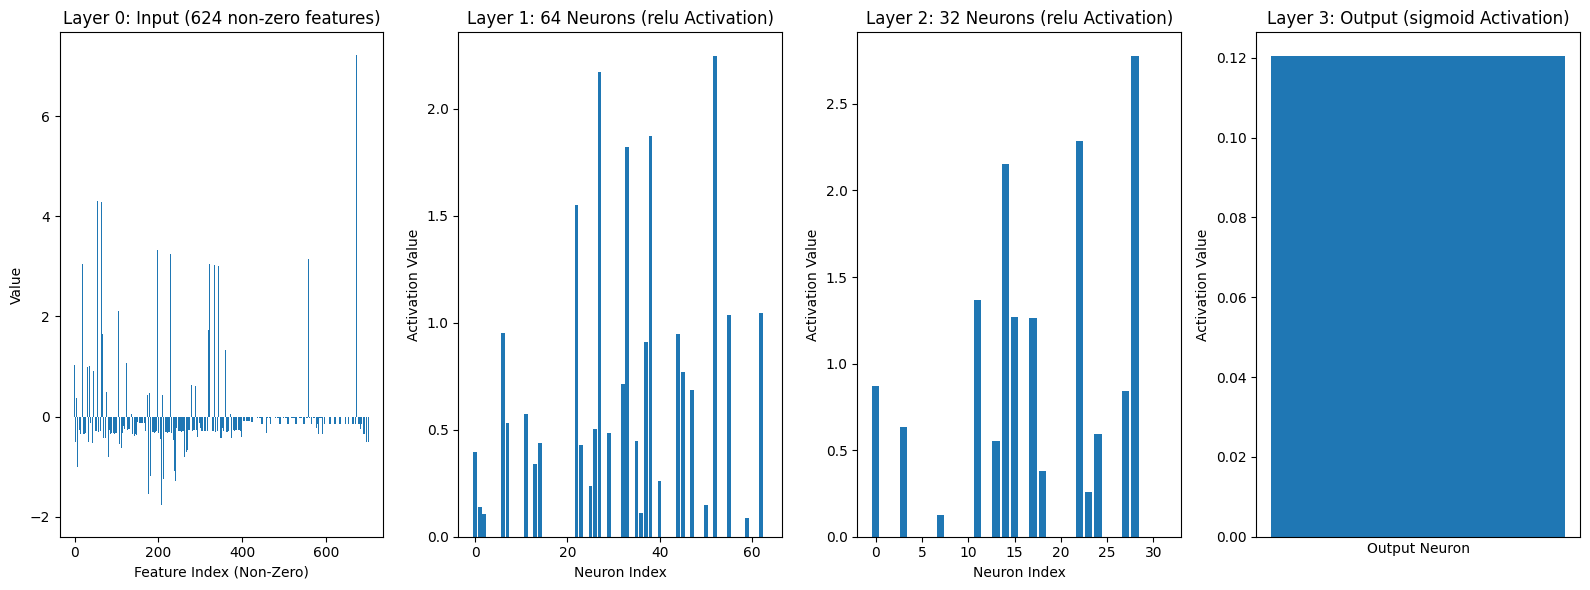


Output Layer (Layer 3) Value for example 0: 0.1204
This value represents the probability of the positive class (e.g., fraud).


In [143]:
def visualize_activations(nn_instance, caches, example_idx=0):
    """Visualize the activations for a single example through the network"""
    L = nn_instance.L

    plt.figure(figsize=((L + 1) * 4, 6))

    plt.subplot(1, L + 1, 1)
    input_values = caches['A0'][example_idx, :]
    non_zero_indices = np.where(input_values != 0)[0]
    if len(non_zero_indices) > 0:
        plt.bar(non_zero_indices, input_values[non_zero_indices])
        plt.title(f'Layer 0: Input ({len(non_zero_indices)} non-zero features)')
        plt.xlabel('Feature Index (Non-Zero)')
    else:
        plt.bar(range(input_values.shape[0]), input_values)
        plt.title(f'Layer 0: Input (All Zero for this example)')
        plt.xlabel('Feature Index')
    plt.ylabel('Value')

    for l in range(1, L + 1):
        plt.subplot(1, L + 1, l + 1)
        current_A = caches[f'A{l}']
        activation_name = nn_instance.activations[l-1]
        if current_A.shape[1] == 1:
            plt.bar([0], current_A[example_idx, :])
            plt.xticks([])
            plt.title(f'Layer {l}: Output ({activation_name} Activation)')
            plt.xlabel('Output Neuron')
        else:
            plt.bar(range(current_A.shape[1]), current_A[example_idx, :])
            plt.title(f'Layer {l}: {nn_instance.layer_dims[l]} Neurons ({activation_name} Activation)')
            plt.xlabel('Neuron Index')
        plt.ylabel('Activation Value')

    plt.tight_layout()
    plt.show()

    output_value = caches[f'A{L}'][example_idx, 0]
    print(f"\nOutput Layer (Layer {L}) Value for example {example_idx}: {output_value:.4f}")
    if nn_instance.activations[L-1] == "sigmoid":
        print("This value represents the probability of the positive class (e.g., fraud).")

visualize_activations(nn, caches)

# TensorFlow

In [144]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

tf.random.set_seed(42)

input_features = X_train_poly.shape[1]

tf_model = Sequential([
   Input(shape=(input_features,)),
   Dense(64, activation='relu'),
   Dense(32, activation='relu'),
   Dense(1, activation='sigmoid')
])

tf_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        44,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,105 (184.00 KB)

 Trainable params: 47,105 (184.00 KB)

 Non-trainable params: 0 (0.00 B)

In [145]:
X_tf = X_train_poly

tf_output = tf_model.predict(X_tf)

print(f"TensorFlow output shape: {tf_output.shape}")
print(f"TensorFlow output values:\n{tf_output}")

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
TensorFlow output shape: (80000, 1)
TensorFlow output values:
[[0.48016533]
 [0.01333021]
 [0.05430246]
 ...
 [0.21979143]
 [0.12328795]
 [0.11792285]]


## PyTorch

In [146]:
import torch
import torch.nn as nn

torch.manual_seed(42)

input_features = X_train_poly.shape[1]

hidden1_dim = 64
hidden2_dim = 32
output_dim = 1

class PyTorchNN(nn.Module):
   def __init__(self, input_dim, hidden1_dim, hidden2_dim, output_dim):
       super(PyTorchNN, self).__init__()
       self.fc1 = nn.Linear(input_dim, hidden1_dim)
       self.relu1 = nn.ReLU()
       self.fc2 = nn.Linear(hidden1_dim, hidden2_dim)
       self.relu2 = nn.ReLU()
       self.fc3 = nn.Linear(hidden2_dim, output_dim)
       self.sigmoid = nn.Sigmoid()

   def forward(self, x):
       x = self.fc1(x)
       x = self.relu1(x)
       x = self.fc2(x)
       x = self.relu2(x)
       x = self.fc3(x)
       x = self.sigmoid(x)
       return x

torch_model = PyTorchNN(input_features, hidden1_dim, hidden2_dim, output_dim)

print(torch_model)

X_torch = torch.tensor(X_train_poly, dtype=torch.float32)

with torch.no_grad():
    torch_output = torch_model(X_torch)

print(f"\nPyTorch output shape: {torch_output.shape}")
print(f"PyTorch output values (first 5):\n{torch_output[:5]}")

PyTorchNN(
  (fc1): Linear(in_features=702, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

PyTorch output shape: torch.Size([80000, 1])
PyTorch output values (first 5):
tensor([[0.4594],
        [0.4312],
        [0.4572],
        [0.4582],
        [0.4659]])


In [147]:
print("\nComparison of implementations:")
print(f"NumPy output shape: {output.shape}")
print(f"TensorFlow output shape: {tf_output.shape}")
print(f"PyTorch output shape: {torch_output.shape}")


Comparison of implementations:
NumPy output shape: (80000, 1)
TensorFlow output shape: (80000, 1)
PyTorch output shape: torch.Size([80000, 1])


# Backward Propagation

In [148]:
input_dim = X_train_poly.shape[1]
output_dim = 1

layer_dims = [input_dim, 64, 32, output_dim]
activations = ["relu", "relu", "sigmoid"]

print(f"Network Architecture Defined:")
print(f"  Input Layer Dimension: {layer_dims[0]} features")
print(f"  Hidden Layer 1 Dimension: {layer_dims[1]} neurons with {activations[0]} activation")
print(f"  Hidden Layer 2 Dimension: {layer_dims[2]} neurons with {activations[1]} activation")
print(f"  Output Layer Dimension: {layer_dims[3]} neuron with {activations[2]} activation")

Network Architecture Defined:
  Input Layer Dimension: 702 features
  Hidden Layer 1 Dimension: 64 neurons with relu activation
  Hidden Layer 2 Dimension: 32 neurons with relu activation
  Output Layer Dimension: 1 neuron with sigmoid activation


In [149]:
nn = NeuralNetwork(layer_dims, activations)

output, caches = nn.forward_propagation(X_train_poly)

print(f"Input data shape (X_train_poly): {X_train_poly.shape}")
print(f"Output of the neural network shape: {output.shape}")
print(f"Sample of output values (first 5):\n{output[:5]}")

Input data shape (X_train_poly): (80000, 702)
Output of the neural network shape: (80000, 1)
Sample of output values (first 5):
[[0.27067827]
 [0.28090894]
 [0.3395432 ]
 [0.14097294]
 [0.20989649]]


### Binary Cross-Entropy Loss

In [150]:
def compute_cost(AL, Y):
    """
    Computes the binary cross-entropy cost function.

    Parameters:
    - AL: Probability vector corresponding to your label predictions, shape (batch_size, 1)
    - Y: True "label" vector (0 if non-fraud, 1 if fraud), shape (batch_size, 1)

    Returns:
    - cost: The binary cross-entropy cost
    """
    m = Y.shape[0]

    cost = -1/m * np.sum(Y * np.log(AL + 1e-9) + (1 - Y) * np.log(1 - AL + 1e-9))

    cost = np.squeeze(cost)
    assert(cost.shape == ())

    return cost

### Backward Propagation

In [151]:
def relu_backward(dA, Z):
    """
    Backward pass for ReLU activation.

    Parameters:
    - dA: Post-activation gradient (from subsequent layer)
    - Z: Pre-activation parameter

    Returns:
    - dZ: Gradient of the cost with respect to Z
    """
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

def sigmoid_backward(dA, Z):
    """
    Backward pass for Sigmoid activation.

    Parameters:
    - dA: Post-activation gradient (from subsequent layer)
    - Z: Pre-activation parameter

    Returns:
    - dZ: Gradient of the cost with respect to Z
    """
    s = 1 / (1 + np.exp(-Z))
    dZ = dA * s * (1 - s)
    return dZ

class NeuralNetworkBP(NeuralNetwork):
    """
    Extends NeuralNetwork class to include backward propagation.
    """
    def backward_propagation(self, AL, Y, caches):
        """
        Implement the backward propagation for the neural network.

        Parameters:
        - AL: Probability vector, output of the forward propagation (L_model_forward())
        - Y: True "label" vector (0 if non-fraud, 1 if fraud), shape (batch_size, 1)
        - caches: List of dictionaries containing all activations (A) and pre-activations (Z) from forward_propagation

        Returns:
        - grads: Dictionary containing gradients with respect to W and b for each layer
        """
        grads = {}
        m = AL.shape[0]

        Y = Y.reshape(AL.shape)


        dZ_L = AL - Y

        for l in reversed(range(1, self.L + 1)):
            A_prev = caches[f'A{l-1}']
            W_l = self.parameters[f'W{l}']

            grads[f'dW{l}'] = 1/m * np.dot(A_prev.T, dZ_L)
            grads[f'db{l}'] = 1/m * np.sum(dZ_L, axis=0, keepdims=True)
            dA_prev = np.dot(dZ_L, W_l.T)

            if l > 1:
                Z_prev = caches[f'Z{l-1}']
                activation_func_prev = self.activations[l-2]

                if activation_func_prev == "relu":
                    dZ_L = relu_backward(dA_prev, Z_prev)
                elif activation_func_prev == "sigmoid":
                    dZ_L = sigmoid_backward(dA_prev, Z_prev)
                else:
                    raise ValueError(f"Unsupported activation function for backward pass: {activation_func_prev}")

        return grads

In [152]:
class NeuralNetworkOptimizer(NeuralNetworkBP):
    """
    Extends NeuralNetworkBP class to include parameter optimization.
    """
    def update_parameters(self, grads, learning_rate):
        """
        Update parameters using gradient descent.

        Parameters:
        - grads: Dictionary containing gradients with respect to W and b for each layer
        - learning_rate: Learning rate for gradient descent
        """
        for l in range(1, self.L + 1):
            self.parameters[f'W{l}'] -= learning_rate * grads[f'dW{l}']
            self.parameters[f'b{l}'] -= learning_rate * grads[f'db{l}']

## Training Loop

Epoch 0: Cost = 0.5024
Epoch 10: Cost = 0.3181
Epoch 20: Cost = 0.2388
Epoch 30: Cost = 0.1968
Epoch 40: Cost = 0.1715
Epoch 50: Cost = 0.1548
Epoch 60: Cost = 0.1432
Epoch 70: Cost = 0.1346
Epoch 80: Cost = 0.1280
Epoch 90: Cost = 0.1228


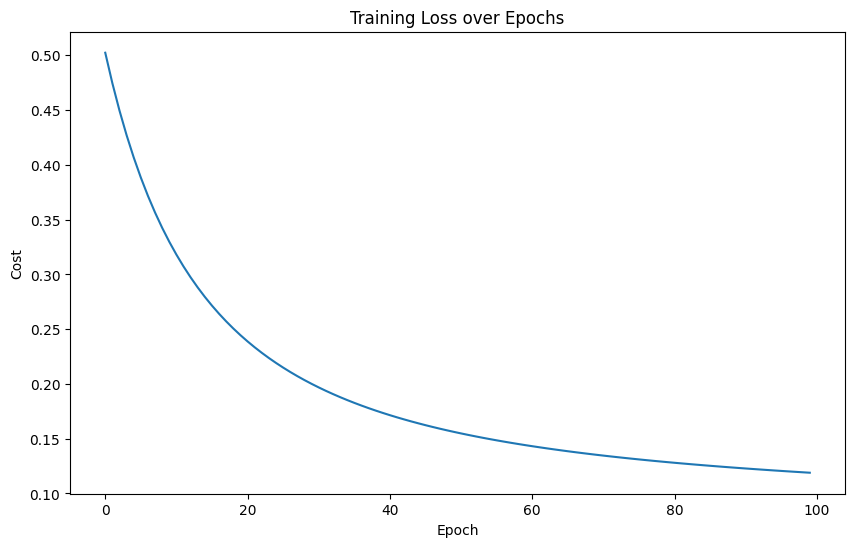

In [153]:
model_nn = NeuralNetworkOptimizer(layer_dims, activations)

epochs = 100
learning_rate = 0.01

train_losses = []

for epoch in range(epochs):
    AL, caches = model_nn.forward_propagation(X_train_poly)

    cost = compute_cost(AL, y_train_small.values.reshape(-1, 1))

    grads = model_nn.backward_propagation(AL, y_train_small.values.reshape(-1, 1), caches)

    model_nn.update_parameters(grads, learning_rate)

    train_losses.append(cost)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Cost = {cost:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Training Loss over Epochs")
plt.show()


Epoch 0: Cost = 0.6887
Epoch 10: Cost = 0.4330
Epoch 20: Cost = 0.3170
Epoch 30: Cost = 0.2539
Epoch 40: Cost = 0.2152
Epoch 50: Cost = 0.1894
Epoch 60: Cost = 0.1713
Epoch 70: Cost = 0.1579
Epoch 80: Cost = 0.1478
Epoch 90: Cost = 0.1398


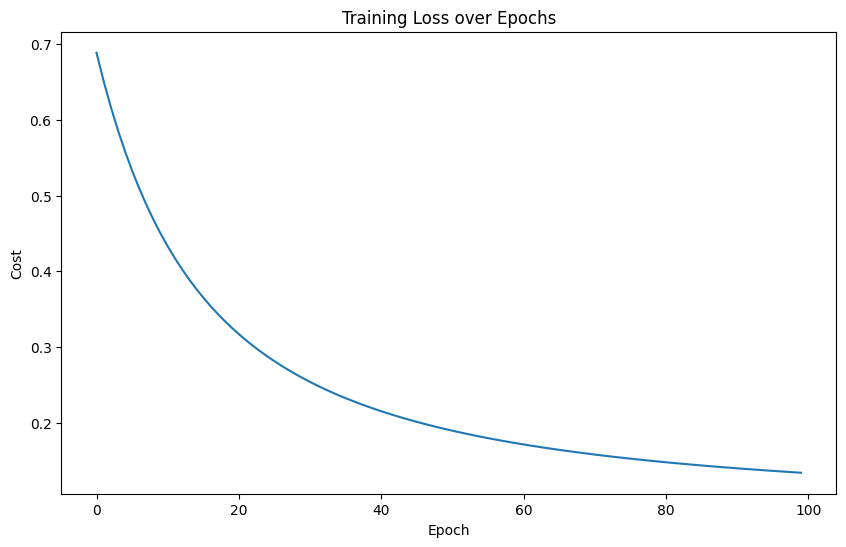

In [154]:
model_nn = NeuralNetworkOptimizer(layer_dims, activations)

epochs = 100
learning_rate = 0.01

train_losses = []

for epoch in range(epochs):
    AL, caches = model_nn.forward_propagation(X_train_poly)

    cost = compute_cost(AL, y_train_small.values.reshape(-1, 1))

    grads = model_nn.backward_propagation(AL, y_train_small.values.reshape(-1, 1), caches)

    model_nn.update_parameters(grads, learning_rate)

    train_losses.append(cost)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Cost = {cost:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Training Loss over Epochs")
plt.show()


In [155]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

AL_test, _ = model_nn.forward_propagation(X_test_poly)

y_pred_test = (AL_test > 0.5).astype(int)

y_test_reshaped = y_test.values.reshape(-1, 1)

print("--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_reshaped, y_pred_test):.4f}")
print(f"F1 Score: {f1_score(y_test_reshaped, y_pred_test):.4f}")
print(f"AUC-ROC Score: {roc_auc_score(y_test_reshaped, AL_test):.4f}")
print(f"Precision Score: {precision_score(y_test_reshaped, y_pred_test):.4f}")
print(f"Recall Score: {recall_score(y_test_reshaped, y_pred_test):.4f}")

--- Model Evaluation ---
Accuracy: 0.9810
F1 Score: 0.0000
AUC-ROC Score: 0.5154
Precision Score: 0.0000
Recall Score: 0.0000


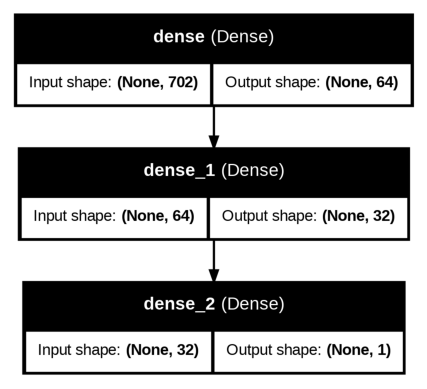

In [156]:
# !pip install tensorflow pydot graphviz

from keras.utils import plot_model
import matplotlib.pyplot as plt

plot_model(tf_model, to_file='network_architecture.png', show_shapes=True, show_layer_names=True)

img = plt.imread('network_architecture.png')
plt.imshow(img)
plt.axis('off')
plt.show()

# Hyparameter Tuning

In [157]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

In [158]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 120),
    'max_depth': [10, 20, None],
    'min_samples_split': randint(2, 6)
}

rf = RandomForestClassifier()

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f6238eafc80>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f6238ec17f0>},
                   verbose=2)

In [159]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_jobs=-1,
    random_state=42
)

param_dist = {
    'n_estimators': randint(30, 100),
    'max_depth': [10, 20, None],
    'min_samples_split': randint(2, 6)
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 3, 'n_estimators': 82}
Best Score: 0.7582619390018756


In [160]:
# pip install optuna

In [161]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 30, 100)
    max_depth = trial.suggest_int('max_depth', 10, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 6)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        n_jobs=-1,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring='f1',
        n_jobs=-1
    ).mean()

    return score

study = optuna.create_study(direction='maximize')

study.optimize(
    objective,
    n_trials=10,
    show_progress_bar=True
)

print("Best Parameters:", study.best_params)
print("Best Score:", study.best_value)

[I 2026-04-20 14:43:39,795] A new study created in memory with name: no-name-765059a6-77d6-4fce-ad6f-6e30d1d4c3e7


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-04-20 14:45:07,160] Trial 0 finished with value: 0.7591795801394546 and parameters: {'n_estimators': 53, 'max_depth': 13, 'min_samples_split': 3}. Best is trial 0 with value: 0.7591795801394546.
[I 2026-04-20 14:46:20,117] Trial 1 finished with value: 0.7548859288276781 and parameters: {'n_estimators': 54, 'max_depth': 16, 'min_samples_split': 5}. Best is trial 0 with value: 0.7591795801394546.
[I 2026-04-20 14:47:43,980] Trial 2 finished with value: 0.7578837646398803 and parameters: {'n_estimators': 71, 'max_depth': 29, 'min_samples_split': 2}. Best is trial 0 with value: 0.7591795801394546.
[I 2026-04-20 14:49:16,159] Trial 3 finished with value: 0.7586326353304064 and parameters: {'n_estimators': 99, 'max_depth': 12, 'min_samples_split': 4}. Best is trial 0 with value: 0.7591795801394546.
[I 2026-04-20 14:50:10,431] Trial 4 finished with value: 0.757437333118525 and parameters: {'n_estimators': 42, 'max_depth': 18, 'min_samples_split': 4}. Best is trial 0 with value: 0.7591

### Final Model Evaluation

--- RandomForestClassifier Tuned Model Evaluation ---

Accuracy: 0.9927
F1 Score: 0.7768
AUC-ROC Score: 0.9464
Precision Score: 0.9191
Recall Score: 0.6726


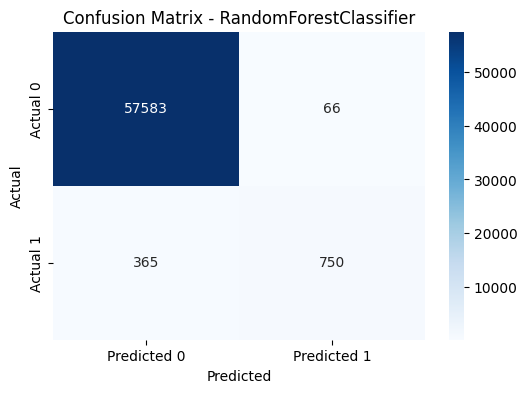

In [162]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_rf_model = random_search.best_estimator_

y_pred_rf = best_rf_model.predict(X_test)
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]

print('--- RandomForestClassifier Tuned Model Evaluation ---\n')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred_rf):.4f}')
print(f'AUC-ROC Score: {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'Precision Score: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall Score: {recall_score(y_test, y_pred_rf):.4f}')

cm = confusion_matrix(y_test, y_pred_rf)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - RandomForestClassifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Final Model Evaluation with Optuna Tuned RandomForestClassifier

--- Optuna Tuned RandomForestClassifier Model Evaluation ---

Accuracy: 0.9925
F1 Score: 0.7714
AUC-ROC Score: 0.9620
Precision Score: 0.9140
Recall Score: 0.6673


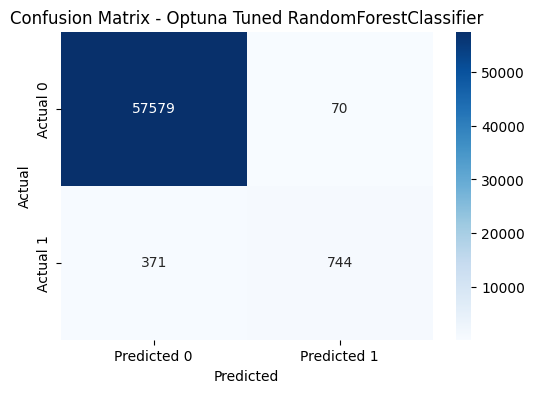

In [163]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_params = study.best_params

best_rf_model_optuna = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    n_jobs=-1,
    random_state=42
)

best_rf_model_optuna.fit(X_train, y_train)

y_pred_optuna = best_rf_model_optuna.predict(X_test)
y_prob_optuna = best_rf_model_optuna.predict_proba(X_test)[:, 1]

print('--- Optuna Tuned RandomForestClassifier Model Evaluation ---\n')
print(f'Accuracy: {accuracy_score(y_test, y_pred_optuna):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred_optuna):.4f}')
print(f'AUC-ROC Score: {roc_auc_score(y_test, y_prob_optuna):.4f}')
print(f'Precision Score: {precision_score(y_test, y_pred_optuna):.4f}')
print(f'Recall Score: {recall_score(y_test, y_pred_optuna):.4f}')

cm_optuna = confusion_matrix(y_test, y_pred_optuna)
cm_df_optuna = pd.DataFrame(cm_optuna, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df_optuna, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Optuna Tuned RandomForestClassifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()